# Project Note 1

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
root_path = 'drive/MyDrive/DSBA/Capstone Project'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
cric = pd.read_excel('//content/drive/MyDrive/DSBA/Capstone Project/Sports Data.xlsx',sheet_name = 'Sports data for DSBA')

## 2)Data Report

In [ ]:
cric.head()

,Game_number,Result,Avg_team_Age,Match_light_type,Match_format,Bowlers_in_team,Wicket_keeper_in_team,All_rounder_in_team,First_selection,Opponent,...,Max_run_scored_1over,Max_wicket_taken_1over,Extra_bowls_bowled,Min_run_given_1over,Min_run_scored_1over,Max_run_given_1over,extra_bowls_opponent,player_highest_run,Players_scored_zero,player_highest_wicket
0,Game_1,Loss,18.0,Day,ODI,3.0,1,3.0,Bowling,Srilanka,...,13.0,3,0.0,2,3.0,6.0,0,54.0,3,1
1,Game_2,Win,24.0,Day,T20,3.0,1,4.0,Batting,Zimbabwe,...,12.0,1,0.0,0,3.0,6.0,0,69.0,2,1
2,Game_3,Loss,24.0,Day and Night,T20,3.0,1,2.0,Bowling,Zimbabwe,...,14.0,4,0.0,0,3.0,6.0,0,69.0,3,1
3,Game_4,Win,24.0,NaN,ODI,2.0,1,2.0,Bowling,Kenya,...,15.0,4,0.0,2,3.0,6.0,0,73.0,3,1
4,Game_5,Loss,24.0,Night,ODI,1.0,1,3.0,Bowling,Srilanka,...,12.0,4,0.0,0,3.0,6.0,0,80.0,3,1


In [ ]:
cric.shape

(2930, 23)

We understand that our data frame has 2930 rows and 23 columns.

In [ ]:
cric.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Game_number             2930 non-null   object 
 1   Result                  2930 non-null   object 
 2   Avg_team_Age            2833 non-null   float64
 3   Match_light_type        2878 non-null   object 
 4   Match_format            2860 non-null   object 
 5   Bowlers_in_team         2848 non-null   float64
 6   Wicket_keeper_in_team   2930 non-null   int64  
 7   All_rounder_in_team     2890 non-null   float64
 8   First_selection         2871 non-null   object 
 9   Opponent                2894 non-null   object 
 10  Season                  2868 non-null   object 
 11  Audience_number         2849 non-null   float64
 12  Offshore                2866 non-null   object 
 13  Max_run_scored_1over    2902 non-null   float64
 14  Max_wicket_taken_1over  2930 non-null   

In [ ]:
cric.describe().T

,count,mean,std,min,25%,50%,75%,max
Avg_team_Age,2833.0,29.242852,2.264230,12.0,30.0,30.0,30.00,70.0
Bowlers_in_team,2848.0,2.913624,1.023907,1.0,2.0,3.0,4.00,5.0
Wicket_keeper_in_team,2930.0,1.000000,0.000000,1.0,1.0,1.0,1.00,1.0
All_rounder_in_team,2890.0,2.722491,1.092699,1.0,2.0,3.0,4.00,4.0
Audience_number,2849.0,46267.960688,48599.581459,7063.0,20363.0,34349.0,57876.00,1399930.0
Max_run_scored_1over,2902.0,15.199862,3.661010,11.0,12.0,14.0,18.00,25.0
Max_wicket_taken_1over,2930.0,2.713993,1.080623,1.0,2.0,3.0,4.00,4.0
Extra_bowls_bowled,2901.0,11.252671,7.780829,0.0,6.0,10.0,15.00,40.0
Min_run_given_1over,2930.0,1.952560,1.678332,0.0,0.0,2.0,3.00,6.0
Min_run_scored_1over,2903.0,2.762659,0.705759,1.0,2.0,3.0,3.00,4.0


When describing our data set, we can see the total count of data for each of the variables along with the statistics like mean, standard deviation, minimum value, maximum value, 25th, 50th and 75th percentile values.
 - We can see that the wicket keeper in the team holds 1 across all the records, as this is a constant value we can remove from our data before proceeding for analysis.
 - The maximum value for the Audience number seems too off based on the 75th percentile value.
 - We can also see that the minimum average team age of 12 and the maximum average team age to be 70 which does not make sense.

## 3) Exploratory data analysis

As seen from the output of the info function that few of the columns have null values in them, let us see below the null valuesfor each column.

In [ ]:
cric.isnull().sum()

Game_number                0
Result                     0
Avg_team_Age              97
Match_light_type          52
Match_format              70
Bowlers_in_team           82
Wicket_keeper_in_team      0
All_rounder_in_team       40
First_selection           59
Opponent                  36
Season                    62
Audience_number           81
Offshore                  64
Max_run_scored_1over      28
Max_wicket_taken_1over     0
Extra_bowls_bowled        29
Min_run_given_1over        0
Min_run_scored_1over      27
Max_run_given_1over       34
extra_bowls_opponent       0
player_highest_run        28
Players_scored_zero        0
player_highest_wicket      0
dtype: int64

Let us now check the unique values in all the columns.

In [ ]:
results = []
for col in cric.columns:
  unique_values = cric[col].unique()
  count = len(unique_values)
  results.append([col, count, unique_values])

In [ ]:
df = pd.DataFrame(results, columns=['Column', 'Unique Values', 'Values'])
df

,Column,Unique Values,Values
0,Game_number,2930,"[Game_1, Game_2, Game_3, Game_4, Game_5, Game_..."
1,Result,2,"[Loss, Win]"
2,Avg_team_Age,14,"[18.0, 24.0, nan, 17.0, 12.0, 25.0, 26.0, 27.0..."
3,Match_light_type,4,"[Day, Day and Night, nan, Night]"
4,Match_format,5,"[ODI, T20, Test, 20-20, nan]"
5,Bowlers_in_team,6,"[3.0, 2.0, 1.0, nan, 4.0, 5.0]"
6,Wicket_keeper_in_team,1,[1]
7,All_rounder_in_team,5,"[3.0, 4.0, 2.0, 1.0, nan]"
8,First_selection,4,"[Bowling, Batting, Bat, nan]"
9,Opponent,10,"[Srilanka, Zimbabwe, Kenya, Australia, England..."


Looking at the above list of unique values let us check the count of the unique values for the columns.

In [ ]:
cric['Players_scored_zero'].value_counts()

Players_scored_zero
3        1730
2         744
4         285
1         166
Three       5
Name: count, dtype: int64

In [ ]:
cric['player_highest_wicket'].value_counts()

player_highest_wicket
1        1084
2        1063
3         427
4         211
5         138
Three       7
Name: count, dtype: int64

In [ ]:
cric['First_selection'].value_counts()

First_selection
Bowling    1722
Batting    1138
Bat          11
Name: count, dtype: int64

In [ ]:
cric['Match_format'].value_counts()

Match_format
ODI      1865
T20       864
Test      125
20-20       6
Name: count, dtype: int64

Replacing the values 'Three' with 3 in columns Players_scored_zero and player_highest_wicket.

Replacing the values 'Bat' with 'Batting' in column First_selection

Replacing the values for '20-20' with 'T20' in column Match_format

In [ ]:
cric['Players_scored_zero'].replace('Three',3, inplace =True)
cric['player_highest_wicket'].replace('Three',3, inplace =True)
cric['First_selection'].replace('Bat','Batting', inplace =True)
cric['Match_format'].replace('20-20','T20', inplace =True)

Let us again check the unique values to see if the updates have occured.

In [ ]:
cric['Players_scored_zero'].value_counts()

Players_scored_zero
3    1735
2     744
4     285
1     166
Name: count, dtype: int64

In [ ]:
cric['player_highest_wicket'].value_counts()

player_highest_wicket
1    1084
2    1063
3     434
4     211
5     138
Name: count, dtype: int64

In [ ]:
cric['First_selection'].value_counts()

First_selection
Bowling    1722
Batting    1149
Name: count, dtype: int64

In [ ]:
cric['Match_format'].value_counts()

Match_format
ODI     1865
T20      870
Test     125
Name: count, dtype: int64

Checking the data types after replacing the values.

In [ ]:
cric.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Game_number             2930 non-null   object 
 1   Result                  2930 non-null   object 
 2   Avg_team_Age            2833 non-null   float64
 3   Match_light_type        2878 non-null   object 
 4   Match_format            2860 non-null   object 
 5   Bowlers_in_team         2848 non-null   float64
 6   Wicket_keeper_in_team   2930 non-null   int64  
 7   All_rounder_in_team     2890 non-null   float64
 8   First_selection         2871 non-null   object 
 9   Opponent                2894 non-null   object 
 10  Season                  2868 non-null   object 
 11  Audience_number         2849 non-null   float64
 12  Offshore                2866 non-null   object 
 13  Max_run_scored_1over    2902 non-null   float64
 14  Max_wicket_taken_1over  2930 non-null   

We see that Players_scored_zero and player_highest_wicket have been converted to integer data type.

As per the data definition we can remove the below list of columns as they do not add any value to our model generation.

 - Game_number - Unique ID for each match
 - Wicket_keeper_in_team - as the value is always 1 we will not include it in our analysis.

In [ ]:
cric.drop(columns = ['Game_number'],axis = 0, inplace = True)

In [ ]:
cric.drop(columns = ['Wicket_keeper_in_team'],axis = 0, inplace = True)

In [ ]:
cric

,Result,Avg_team_Age,Match_light_type,Match_format,Bowlers_in_team,All_rounder_in_team,First_selection,Opponent,Season,Audience_number,...,Max_run_scored_1over,Max_wicket_taken_1over,Extra_bowls_bowled,Min_run_given_1over,Min_run_scored_1over,Max_run_given_1over,extra_bowls_opponent,player_highest_run,Players_scored_zero,player_highest_wicket
0,Loss,18.0,Day,ODI,3.0,3.0,Bowling,Srilanka,Summer,9940.0,...,13.0,3,0.0,2,3.0,6.0,0,54.0,3,1
1,Win,24.0,Day,T20,3.0,4.0,Batting,Zimbabwe,Summer,8400.0,...,12.0,1,0.0,0,3.0,6.0,0,69.0,2,1
2,Loss,24.0,Day and Night,T20,3.0,2.0,Bowling,Zimbabwe,NaN,13146.0,...,14.0,4,0.0,0,3.0,6.0,0,69.0,3,1
3,Win,24.0,NaN,ODI,2.0,2.0,Bowling,Kenya,Summer,7357.0,...,15.0,4,0.0,2,3.0,6.0,0,73.0,3,1
4,Loss,24.0,Night,ODI,1.0,3.0,Bowling,Srilanka,Summer,13328.0,...,12.0,4,0.0,0,3.0,6.0,0,80.0,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,Win,30.0,Day,T20,3.0,4.0,Batting,South Africa,Summer,33950.0,...,15.0,3,8.0,0,3.0,6.0,3,50.0,3,2
2926,Win,30.0,Day,ODI,4.0,3.0,Bowling,Kenya,Summer,19663.0,...,14.0,4,8.0,2,3.0,6.0,2,52.0,2,1
2927,Win,30.0,Day and Night,ODI,4.0,3.0,Bowling,Pakistan,Rainy,39823.0,...,14.0,4,10.0,2,4.0,10.0,2,80.0,3,2
2928,Win,30.0,Day,ODI,4.0,3.0,Batting,Kenya,Rainy,14007.0,...,14.0,2,20.0,2,3.0,6.0,3,98.0,3,1


Also we notice that opponent in the data frame has missing values, we could treat them but if we treat these null values there is a chance of biasing of the data which we do not want, hence we will proceed to remove the rows having null values in the oponent column from our data frame.

In [ ]:
cric.dropna(subset = ['Opponent'], inplace = True)

In [ ]:
cric

,Result,Avg_team_Age,Match_light_type,Match_format,Bowlers_in_team,All_rounder_in_team,First_selection,Opponent,Season,Audience_number,...,Max_run_scored_1over,Max_wicket_taken_1over,Extra_bowls_bowled,Min_run_given_1over,Min_run_scored_1over,Max_run_given_1over,extra_bowls_opponent,player_highest_run,Players_scored_zero,player_highest_wicket
0,Loss,18.0,Day,ODI,3.0,3.0,Bowling,Srilanka,Summer,9940.0,...,13.0,3,0.0,2,3.0,6.0,0,54.0,3,1
1,Win,24.0,Day,T20,3.0,4.0,Batting,Zimbabwe,Summer,8400.0,...,12.0,1,0.0,0,3.0,6.0,0,69.0,2,1
2,Loss,24.0,Day and Night,T20,3.0,2.0,Bowling,Zimbabwe,NaN,13146.0,...,14.0,4,0.0,0,3.0,6.0,0,69.0,3,1
3,Win,24.0,NaN,ODI,2.0,2.0,Bowling,Kenya,Summer,7357.0,...,15.0,4,0.0,2,3.0,6.0,0,73.0,3,1
4,Loss,24.0,Night,ODI,1.0,3.0,Bowling,Srilanka,Summer,13328.0,...,12.0,4,0.0,0,3.0,6.0,0,80.0,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,Win,30.0,Day,T20,3.0,4.0,Batting,South Africa,Summer,33950.0,...,15.0,3,8.0,0,3.0,6.0,3,50.0,3,2
2926,Win,30.0,Day,ODI,4.0,3.0,Bowling,Kenya,Summer,19663.0,...,14.0,4,8.0,2,3.0,6.0,2,52.0,2,1
2927,Win,30.0,Day and Night,ODI,4.0,3.0,Bowling,Pakistan,Rainy,39823.0,...,14.0,4,10.0,2,4.0,10.0,2,80.0,3,2
2928,Win,30.0,Day,ODI,4.0,3.0,Batting,Kenya,Rainy,14007.0,...,14.0,2,20.0,2,3.0,6.0,3,98.0,3,1


In [ ]:
cric.isnull().sum()

Result                     0
Avg_team_Age              97
Match_light_type          52
Match_format              70
Bowlers_in_team           82
All_rounder_in_team       40
First_selection           59
Opponent                   0
Season                    62
Audience_number           80
Offshore                  64
Max_run_scored_1over      28
Max_wicket_taken_1over     0
Extra_bowls_bowled        28
Min_run_given_1over        0
Min_run_scored_1over      27
Max_run_given_1over       34
extra_bowls_opponent       0
player_highest_run        28
Players_scored_zero        0
player_highest_wicket      0
dtype: int64

We see that there are no more null values in the opponent column

In [ ]:
cric['Avg_team_Age'].value_counts()

Avg_team_Age
30.0    2167
24.0     184
29.0     131
27.0      92
28.0      92
26.0      74
25.0      50
70.0       2
18.0       1
17.0       1
12.0       1
69.0       1
50.0       1
Name: count, dtype: int64

We observe that there are 7 entries with values that are not practically possible as we have never heard of a team having an avaerage team age of 50,69 or 70, for this to be the case there might be players above 70 in the team which is not practical.

Similarly the average age of 12, 17 and 18 indicate that there are more players in the team whise age is less than the average value.

In [ ]:
cric['Avg_team_Age'].describe()

count    2797.000000
mean       29.233107
std         2.277119
min        12.000000
25%        30.000000
50%        30.000000
75%        30.000000
max        70.000000
Name: Avg_team_Age, dtype: float64

As seen from the above describe function the Q1 or 25 percentile and Q3 or 75 percentile are the same, as a result if we use the IQR method then all the values will be replaced by 30 as the Q1 and Q3 are the same.

Let us try to corelate the values and check for any corealtion

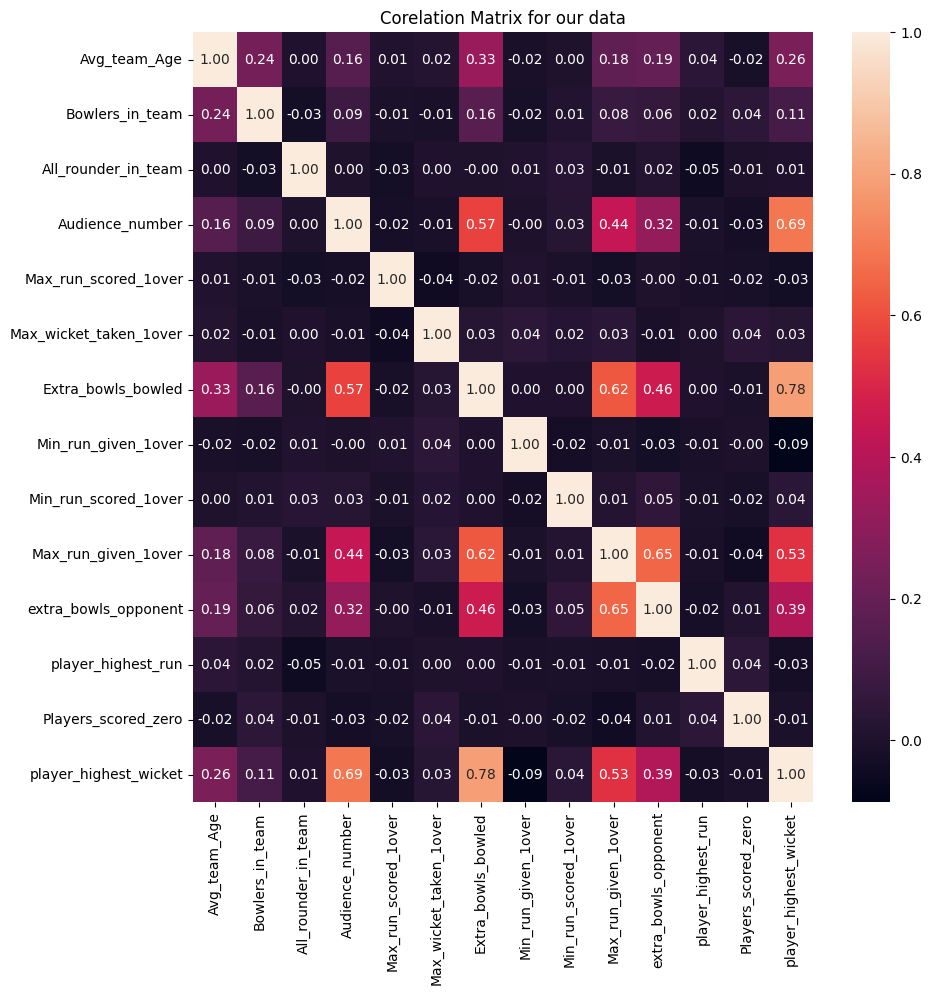

In [ ]:
plt.figure(figsize = (10,10))
plt.title('Corelation Matrix for our data')
sns.heatmap(data= cric[['Avg_team_Age','Bowlers_in_team','All_rounder_in_team','Audience_number','Max_run_scored_1over','Max_wicket_taken_1over','Extra_bowls_bowled','Min_run_given_1over','Min_run_scored_1over','Max_run_given_1over','extra_bowls_opponent','player_highest_run','Players_scored_zero','player_highest_wicket']].corr(),annot = True, fmt='.2f',);

As the corelation between the Average_team_Age and other columns is very low and also probably there could be junk values in this column which may impact our analysis, so we can drop this column from our data frame.

In [ ]:
cric.drop(columns = ['Avg_team_Age'],axis = 0, inplace = True)

In [ ]:
cric.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2894 entries, 0 to 2929
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Result                  2894 non-null   object 
 1   Match_light_type        2842 non-null   object 
 2   Match_format            2824 non-null   object 
 3   Bowlers_in_team         2812 non-null   float64
 4   All_rounder_in_team     2854 non-null   float64
 5   First_selection         2835 non-null   object 
 6   Opponent                2894 non-null   object 
 7   Season                  2832 non-null   object 
 8   Audience_number         2814 non-null   float64
 9   Offshore                2830 non-null   object 
 10  Max_run_scored_1over    2866 non-null   float64
 11  Max_wicket_taken_1over  2894 non-null   int64  
 12  Extra_bowls_bowled      2866 non-null   float64
 13  Min_run_given_1over     2894 non-null   int64  
 14  Min_run_scored_1over    2867 non-null   float

In [ ]:
cric.isnull().sum()

Result                     0
Match_light_type          52
Match_format              70
Bowlers_in_team           82
All_rounder_in_team       40
First_selection           59
Opponent                   0
Season                    62
Audience_number           80
Offshore                  64
Max_run_scored_1over      28
Max_wicket_taken_1over     0
Extra_bowls_bowled        28
Min_run_given_1over        0
Min_run_scored_1over      27
Max_run_given_1over       34
extra_bowls_opponent       0
player_highest_run        28
Players_scored_zero        0
player_highest_wicket      0
dtype: int64

Before imputing the values let us see the count of each unique value in the categorical columns.

In [ ]:
cric['Match_light_type'].value_counts()

Match_light_type
Day              2020
Day and Night     529
Night             293
Name: count, dtype: int64

In [ ]:
cric['Match_format'].value_counts()

Match_format
ODI     1840
T20      859
Test     125
Name: count, dtype: int64

In [ ]:
cric['First_selection'].value_counts()

First_selection
Bowling    1703
Batting    1132
Name: count, dtype: int64

In [ ]:
cric['Season'].value_counts()

Season
Rainy     1292
Summer     908
Winter     632
Name: count, dtype: int64

In [ ]:
cric['Offshore'].value_counts()

Offshore
No     2028
Yes     802
Name: count, dtype: int64

We now proceed to impute the null values in our data set

In [ ]:
cric['Match_light_type'].replace(np.nan,cric['Match_light_type'].mode()[0], inplace=True)
cric['Match_format'].replace(np.nan,cric['Match_format'].mode()[0], inplace=True)
cric['First_selection'].replace(np.nan,cric['First_selection'].mode()[0], inplace=True)
cric['Season'].replace(np.nan,cric['Season'].mode()[0], inplace=True)
cric['Offshore'].replace(np.nan,cric['Offshore'].mode()[0], inplace=True)

In [ ]:
cric['Bowlers_in_team'].replace(np.nan,cric['Bowlers_in_team'].mode()[0], inplace=True)
cric['All_rounder_in_team'].replace(np.nan,cric['All_rounder_in_team'].mode()[0], inplace=True)
cric['Audience_number'].replace(np.nan,round(cric['Audience_number'].mean(),0), inplace=True)
cric['Max_run_scored_1over'].replace(np.nan,round(cric['Max_run_scored_1over'].mean(),0), inplace=True)
cric['Extra_bowls_bowled'].replace(np.nan,round(cric['Extra_bowls_bowled'].mean(),0), inplace=True)
cric['Min_run_scored_1over'].replace(np.nan,cric['Min_run_scored_1over'].mode()[0], inplace=True)
cric['Max_run_given_1over'].replace(np.nan,round(cric['Max_run_given_1over'].mean(),0), inplace=True)
cric['player_highest_run'].replace(np.nan,round(cric['player_highest_run'].mean(),0), inplace=True)

In [ ]:
cric.isnull().sum()

Result                    0
Match_light_type          0
Match_format              0
Bowlers_in_team           0
All_rounder_in_team       0
First_selection           0
Opponent                  0
Season                    0
Audience_number           0
Offshore                  0
Max_run_scored_1over      0
Max_wicket_taken_1over    0
Extra_bowls_bowled        0
Min_run_given_1over       0
Min_run_scored_1over      0
Max_run_given_1over       0
extra_bowls_opponent      0
player_highest_run        0
Players_scored_zero       0
player_highest_wicket     0
dtype: int64

From the above table we observe that all the null values are removed from our data set.

Now there are certain columns in our data set that have values that can be pre defined to take up a set of values then these columns we can convert to categorical data. eg. Bowlers_in_team, All_rounder_in_team, Min_run_given_1over, Min_run_scored_1over, Max_wicket_taken_1over, Players_scored_zero and player_highest_wicket.

In [ ]:
cric['Bowlers_in_team'] = cric['Bowlers_in_team'].astype('category')
cric['All_rounder_in_team'] = cric['All_rounder_in_team'].astype('category')
cric['Min_run_given_1over'] = cric['Min_run_given_1over'].astype('category')
cric['Min_run_scored_1over'] = cric['Min_run_scored_1over'].astype('category')
cric['Max_wicket_taken_1over'] = cric['Max_wicket_taken_1over'].astype('category')
cric['Players_scored_zero'] = cric['Players_scored_zero'].astype('category')
cric['player_highest_wicket'] = cric['player_highest_wicket'].astype('category')

In [ ]:
cric.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2894 entries, 0 to 2929
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   Result                  2894 non-null   object  
 1   Match_light_type        2894 non-null   object  
 2   Match_format            2894 non-null   object  
 3   Bowlers_in_team         2894 non-null   category
 4   All_rounder_in_team     2894 non-null   category
 5   First_selection         2894 non-null   object  
 6   Opponent                2894 non-null   object  
 7   Season                  2894 non-null   object  
 8   Audience_number         2894 non-null   float64 
 9   Offshore                2894 non-null   object  
 10  Max_run_scored_1over    2894 non-null   float64 
 11  Max_wicket_taken_1over  2894 non-null   category
 12  Extra_bowls_bowled      2894 non-null   float64 
 13  Min_run_given_1over     2894 non-null   category
 14  Min_run_scored_1over    2894 

We see that we have successfully converted the data types for the columns and also all the null values have been removed.

Actions performed

 - Dropped the rows with missing values in Opponent Col
 - Imputed categorical missing values using mode
 - Imputed numerical missing values using mean

Let us check for duplicate values in our data set.

In [ ]:
cric.duplicated().sum()

1094

As we see that our data has duplicate values, and duplicate values lead to false statistical significance in analysis and modelling, so we will proceed to remove the duplicate values from our data set.

In [ ]:
cric.drop_duplicates(inplace = True)

In [ ]:
cric.duplicated().sum()

0

We have now successfully removed the duplicate values from our data set.

In [ ]:
num = cric.select_dtypes(include = ['number']).columns
num

Index(['Audience_number', 'Max_run_scored_1over', 'Extra_bowls_bowled',
       'Max_run_given_1over', 'extra_bowls_opponent', 'player_highest_run'],
      dtype='object')

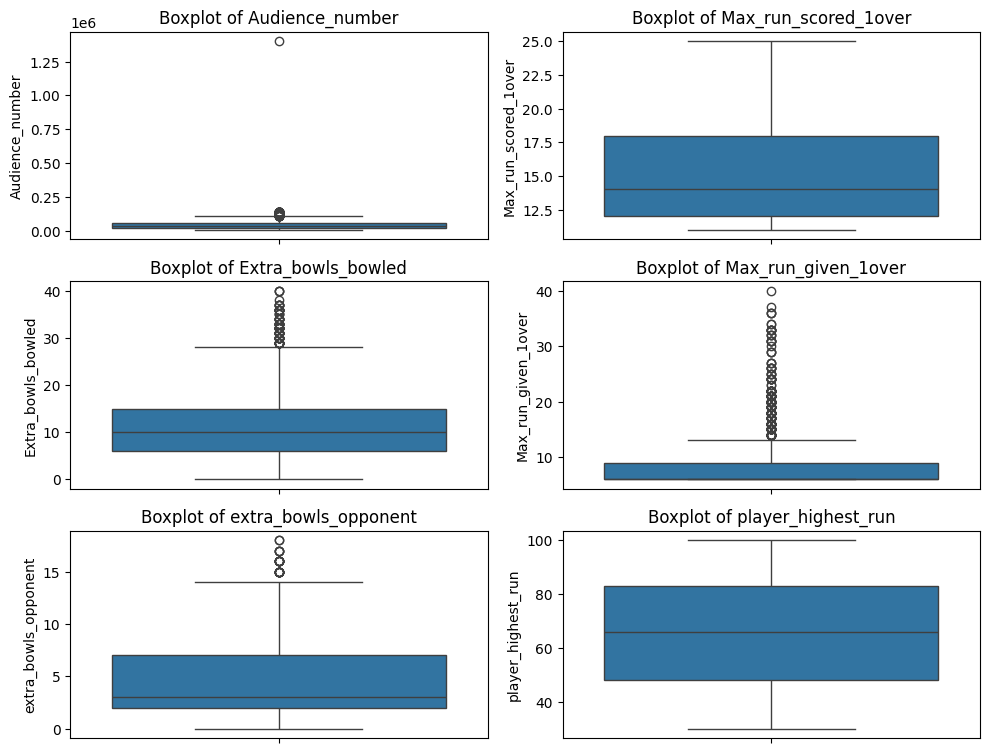

In [ ]:
plt.figure(figsize = (10,50))
#feature_list = cric.columns
for i in range(len(num)):
    plt.subplot(20, 2, i + 1)
    sns.boxplot(y = cric[num[i]], data = cric)
    plt.title('Boxplot of {}'.format(num[i]))
    plt.tight_layout()

We see that there are outliers in our data except for the player_highest_run column.

In this case the column for audience number has an outlier that is not logically possible. so we will go ahead and treat the outlier for this column and the other columns there is a possibility of the value to occur hence we will not be treating them.

In [ ]:
cric['Audience_number'].describe()

count    1.800000e+03
mean     4.634989e+04
std      4.518322e+04
min      7.063000e+03
25%      2.121175e+04
50%      3.613050e+04
75%      5.565700e+04
max      1.399930e+06
Name: Audience_number, dtype: float64

In [ ]:
def detect_outlier(x):
    Q1,Q3=np.percentile(x,[25,75])
    IQR=Q3-Q1
    lower_range= Q1-(1.5*IQR)
    upper_range= Q3+(1.5*IQR)
    return lower_range, upper_range

In [ ]:
lr,ur=detect_outlier(cric['Audience_number'])
cric['Audience_number']=np.where(cric['Audience_number']>ur,ur,cric['Audience_number'])
cric['Audience_number']=np.where(cric['Audience_number']<lr,lr,cric['Audience_number'])

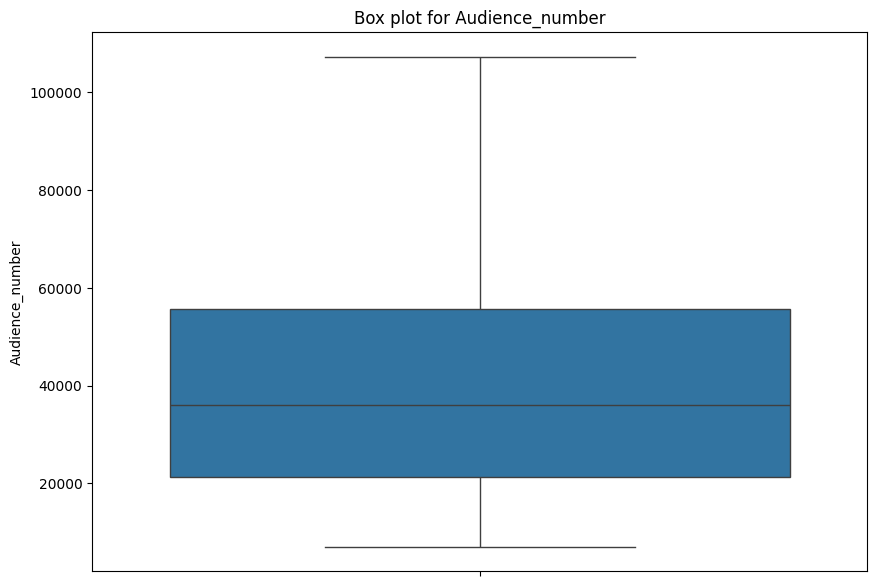

In [ ]:
plt.figure(figsize = (10,7))
plt.title('Box plot for Audience_number')
sns.boxplot(cric['Audience_number']);

We have successfully removed the outlier for the audience number column.

Now we proceed to do the univariate and Bivariate analysis.

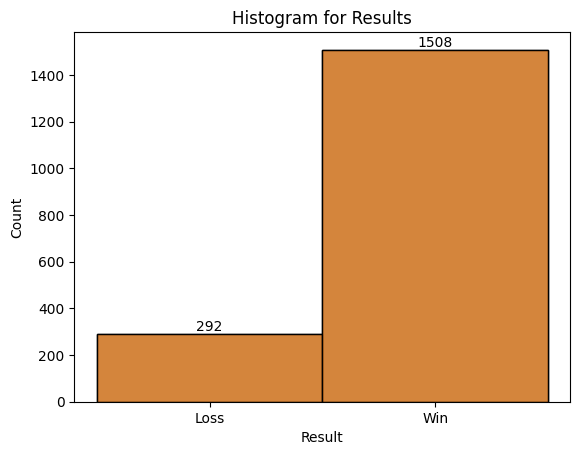

In [ ]:
plt.title('Histogram for Results')
sns.histplot(data = cric, x = 'Result');
plt.bar_label(sns.histplot(data = cric, x = 'Result').containers[0],fontsize=10);

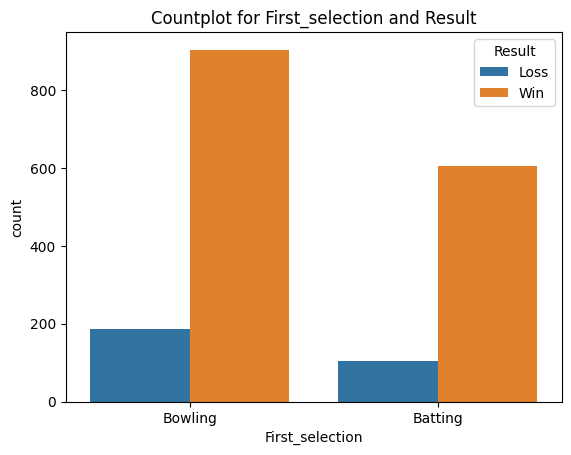

In [ ]:
plt.title('Countplot for First_selection and Result')
sns.countplot(data = cric, x='First_selection', hue = 'Result');

In [ ]:
table = pd.crosstab(cric.First_selection, cric.Result)
table['Total'] = table.sum(axis=1)
print('Crosstab for First selction and Result')
print(table)

Crosstab for First selction and Result
Result           Loss  Win  Total
First_selection                  
Batting           105  605    710
Bowling           187  903   1090


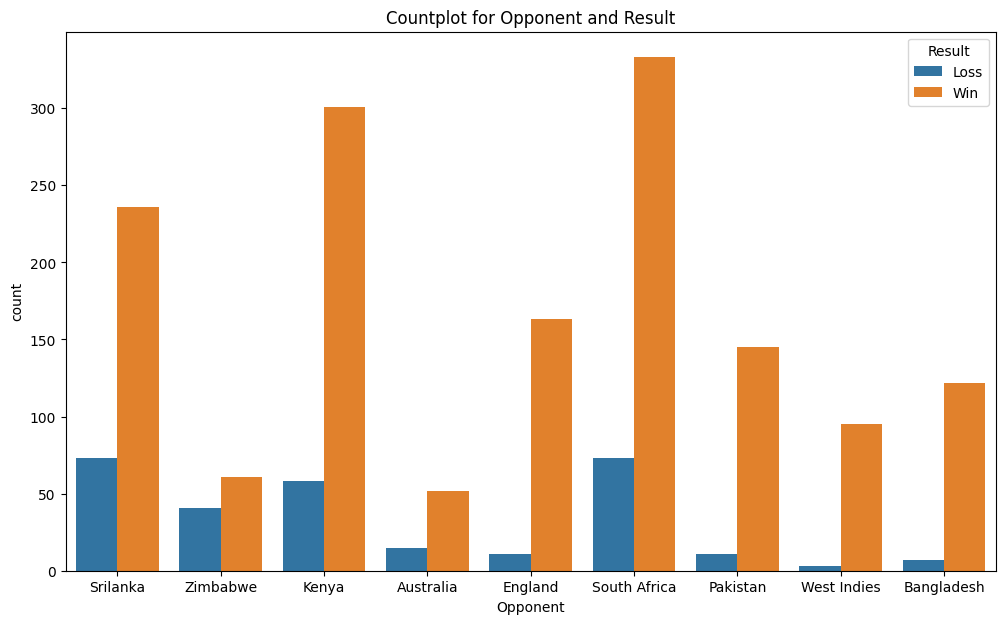

In [ ]:
plt.figure(figsize = (12,7))
plt.title('Countplot for Opponent and Result')
sns.countplot(data = cric, x='Opponent', hue = 'Result');

In [ ]:
table = pd.crosstab(cric.Opponent, cric.Result)
table['Total'] = table.sum(axis=1)
print('Crosstab for Opponent and Result')
print(table)

Crosstab for Opponent and Result
Result        Loss  Win  Total
Opponent                      
Australia       15   52     67
Bangladesh       7  122    129
England         11  163    174
Kenya           58  301    359
Pakistan        11  145    156
South Africa    73  333    406
Srilanka        73  236    309
West Indies      3   95     98
Zimbabwe        41   61    102


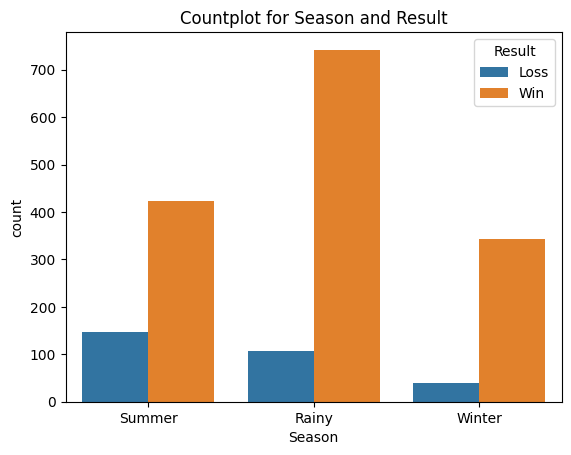

In [ ]:
plt.title('Countplot for Season and Result')
sns.countplot(data = cric, x='Season', hue = 'Result');

In [ ]:
table = pd.crosstab(cric.Season, cric.Result)
table['Total'] = table.sum(axis=1)
print('Crosstab for Season and Result')
print(table)

Crosstab for Season and Result
Result  Loss  Win  Total
Season                  
Rainy    107  742    849
Summer   146  423    569
Winter    39  343    382


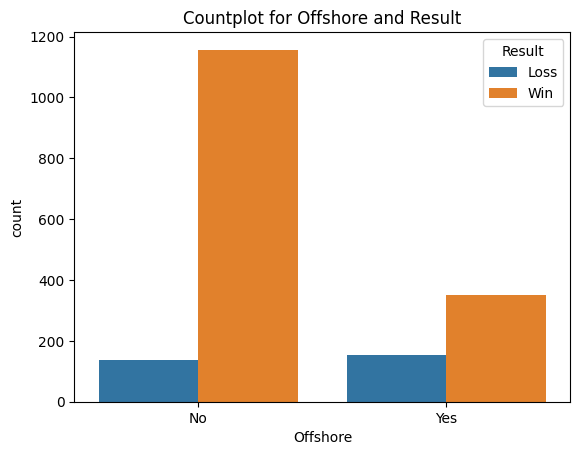

In [ ]:
plt.title('Countplot for Offshore and Result')
sns.countplot(data = cric, x='Offshore', hue = 'Result');

In [ ]:
table = pd.crosstab(cric.Offshore, cric.Result)
table['Total'] = table.sum(axis=1)
print('Crosstab for Offshore and Result')
print(table)

Crosstab for Offshore and Result
Result    Loss   Win  Total
Offshore                   
No         138  1157   1295
Yes        154   351    505


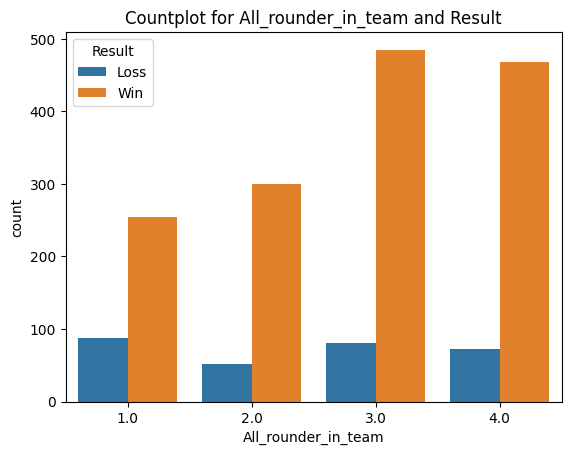

In [ ]:
plt.title('Countplot for All_rounder_in_team and Result')
sns.countplot(data = cric, x='All_rounder_in_team', hue = 'Result');

In [ ]:
table = pd.crosstab(cric.All_rounder_in_team, cric.Result)
table['Total'] = table.sum(axis=1)
print('Crosstab for All_rounder_in_team and Result')
print(table)

Crosstab for All_rounder_in_team and Result
Result               Loss  Win  Total
All_rounder_in_team                  
1.0                    87  255    342
2.0                    52  300    352
3.0                    81  485    566
4.0                    72  468    540


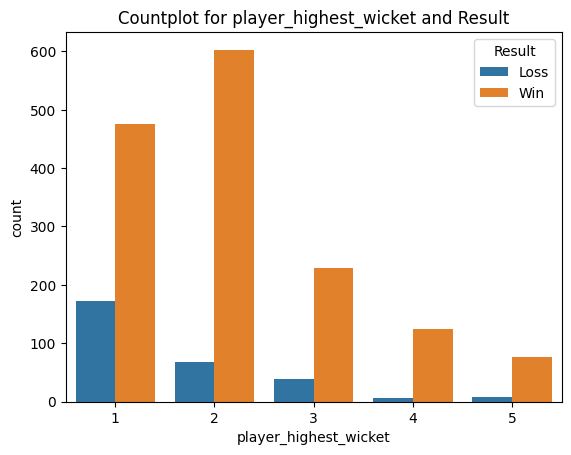

In [ ]:
plt.title('Countplot for player_highest_wicket and Result')
sns.countplot(data = cric, x='player_highest_wicket', hue = 'Result');

In [ ]:
table = pd.crosstab(cric.player_highest_wicket, cric.Result)
table['Total'] = table.sum(axis=1)
print('Crosstab for player_highest_wicket and Result')
print(table)

Crosstab for player_highest_wicket and Result
Result                 Loss  Win  Total
player_highest_wicket                  
1                       172  476    648
2                        67  603    670
3                        39  228    267
4                         6  124    130
5                         8   77     85


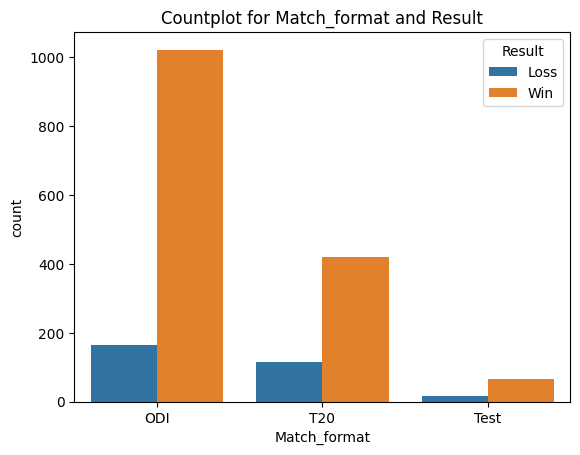

In [ ]:
plt.title('Countplot for Match_format and Result')
sns.countplot(data = cric, x='Match_format', hue = 'Result');

In [ ]:
table = pd.crosstab(cric.Match_format, cric.Result)
table['Total'] = table.sum(axis=1)
print('Crosstab for Match_format and Result')
print(table)

Crosstab for Match_format and Result
Result        Loss   Win  Total
Match_format                   
ODI            163  1023   1186
T20            114   420    534
Test            15    65     80


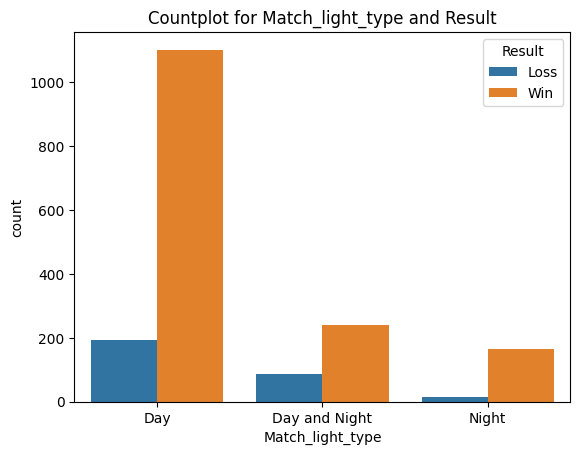

In [ ]:
plt.title('Countplot for Match_light_type and Result')
sns.countplot(data = cric, x='Match_light_type', hue = 'Result');

In [ ]:
table = pd.crosstab(cric.Match_light_type, cric.Result)
table['Total'] = table.sum(axis=1)
print('Crosstab for Match_light_type and Result')
print(table)

Crosstab for Match_light_type and Result
Result            Loss   Win  Total
Match_light_type                   
Day                192  1103   1295
Day and Night       85   239    324
Night               15   166    181


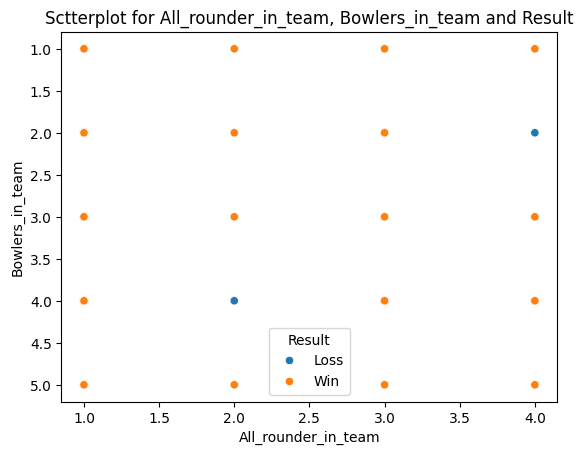

In [ ]:
plt.title('Sctterplot for All_rounder_in_team, Bowlers_in_team and Result')
sns.scatterplot(data = cric, x = 'All_rounder_in_team', y = 'Bowlers_in_team', hue = 'Result');

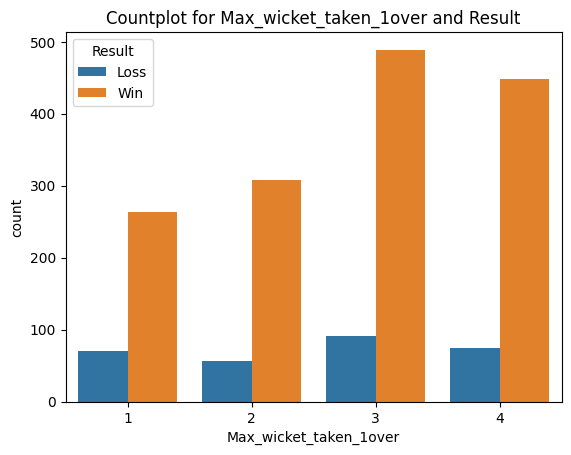

In [ ]:
plt.title('Countplot for Max_wicket_taken_1over and Result')
sns.countplot(data = cric, x='Max_wicket_taken_1over', hue = 'Result');

In [ ]:
table = pd.crosstab(cric.Max_wicket_taken_1over, cric.Result)
table['Total'] = table.sum(axis=1)
print('Crosstab for Max_wicket_taken_1over and Result')
print(table)

Crosstab for Max_wicket_taken_1over and Result
Result                  Loss  Win  Total
Max_wicket_taken_1over                  
1                         70  263    333
2                         56  308    364
3                         91  489    580
4                         75  448    523


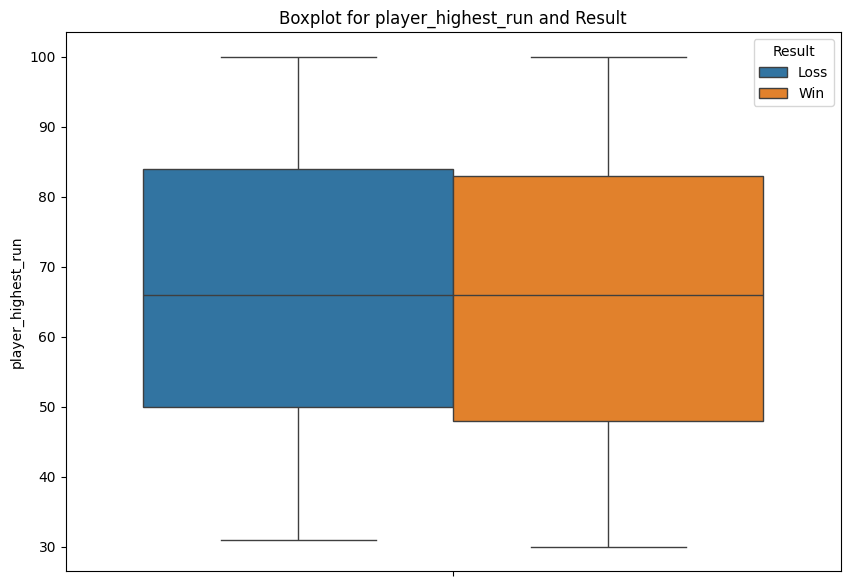

In [ ]:
plt.figure(figsize = (10,7))
plt.title('Boxplot for player_highest_run and Result')
sns.boxplot(data = cric, y='player_highest_run', hue = 'Result');

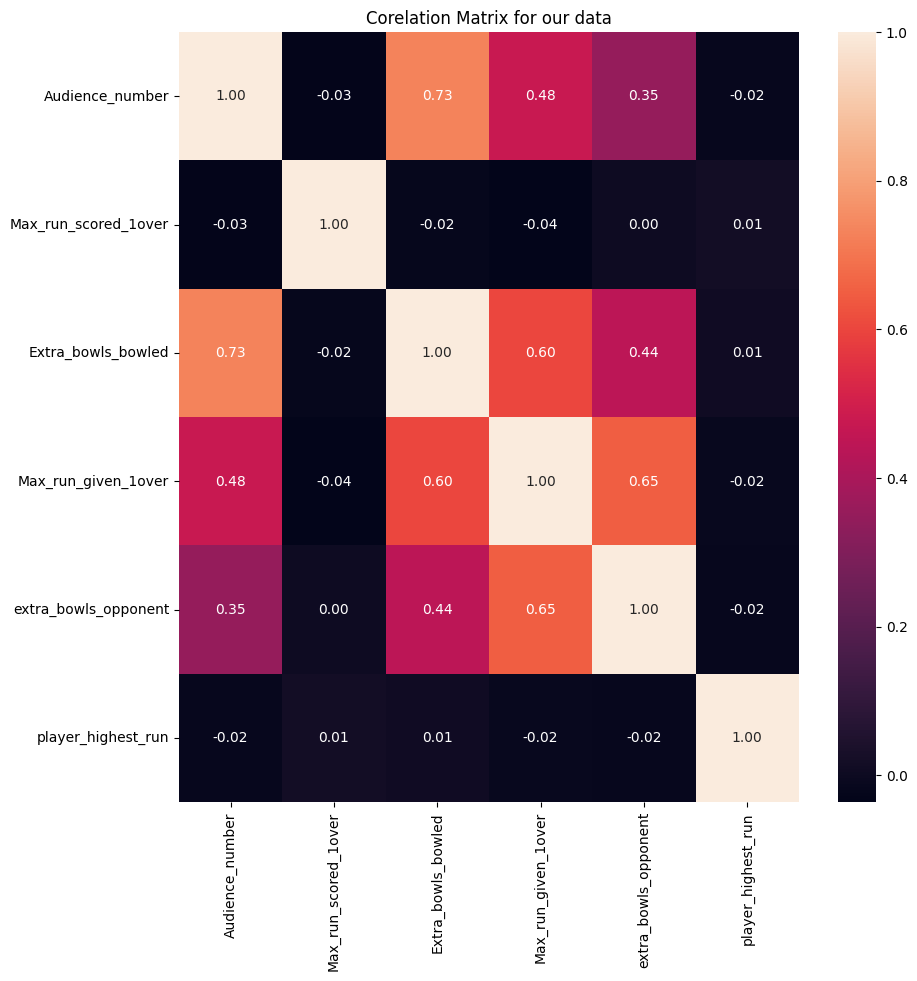

In [ ]:
plt.figure(figsize = (10,10))
plt.title('Corelation Matrix for our data')
sns.heatmap(data= cric[['Audience_number','Max_run_scored_1over','Extra_bowls_bowled','Max_run_given_1over','extra_bowls_opponent','player_highest_run']].corr(),annot = True, fmt='.2f');

In [ ]:
cric_clus = cric.copy()
cric_clus.head()

,Result,Match_light_type,Match_format,Bowlers_in_team,All_rounder_in_team,First_selection,Opponent,Season,Audience_number,Offshore,Max_run_scored_1over,Max_wicket_taken_1over,Extra_bowls_bowled,Min_run_given_1over,Min_run_scored_1over,Max_run_given_1over,extra_bowls_opponent,player_highest_run,Players_scored_zero,player_highest_wicket
0,Loss,Day,ODI,3.0,3.0,Bowling,Srilanka,Summer,9940.0,No,13.0,3,0.0,2,3.0,6.0,0,54.0,3,1
1,Win,Day,T20,3.0,4.0,Batting,Zimbabwe,Summer,8400.0,No,12.0,1,0.0,0,3.0,6.0,0,69.0,2,1
2,Loss,Day and Night,T20,3.0,2.0,Bowling,Zimbabwe,Rainy,13146.0,Yes,14.0,4,0.0,0,3.0,6.0,0,69.0,3,1
3,Win,Day,ODI,2.0,2.0,Bowling,Kenya,Summer,7357.0,No,15.0,4,0.0,2,3.0,6.0,0,73.0,3,1
4,Loss,Night,ODI,1.0,3.0,Bowling,Srilanka,Summer,13328.0,No,12.0,4,0.0,0,3.0,6.0,0,80.0,3,1


## 4) Business insights from EDA

As our targert variable is categorical we will build a classification model.

In [ ]:
categorical_features = ['Result','Match_light_type', 'Match_format', 'First_selection', 'Opponent', 'Season', 'Offshore', 'Max_wicket_taken_1over', 'Min_run_given_1over', 'Min_run_scored_1over', 'Players_scored_zero', 'player_highest_wicket']
encoder = LabelEncoder()
for col in categorical_features:
    cric[col] = encoder.fit_transform(cric[col])

In [ ]:
X = cric.drop(columns = ['Result'],axis = 0)
y = cric['Result']

In [ ]:
y

0       0
1       1
2       0
3       1
4       0
       ..
2921    1
2923    0
2925    1
2927    1
2928    1
Name: Result, Length: 1800, dtype: int64

In [ ]:
X.head()

,Match_light_type,Match_format,Bowlers_in_team,All_rounder_in_team,First_selection,Opponent,Season,Audience_number,Offshore,Max_run_scored_1over,Max_wicket_taken_1over,Extra_bowls_bowled,Min_run_given_1over,Min_run_scored_1over,Max_run_given_1over,extra_bowls_opponent,player_highest_run,Players_scored_zero,player_highest_wicket
0,0,0,3.0,3.0,1,6,1,9940.0,0,13.0,2,0.0,2,2,6.0,0,54.0,2,0
1,0,1,3.0,4.0,0,8,1,8400.0,0,12.0,0,0.0,0,2,6.0,0,69.0,1,0
2,1,1,3.0,2.0,1,8,0,13146.0,1,14.0,3,0.0,0,2,6.0,0,69.0,2,0
3,0,0,2.0,2.0,1,3,1,7357.0,0,15.0,3,0.0,2,2,6.0,0,73.0,2,0
4,2,0,1.0,3.0,1,6,1,13328.0,0,12.0,3,0.0,0,2,6.0,0,80.0,2,0


In [ ]:
rfe = RFE(estimator=LogisticRegression(), n_features_to_select=15)

In [ ]:
rfe.fit(X, y)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

RFE(estimator=LogisticRegression(), n_features_to_select=15)

In [ ]:
rank = rfe.ranking_

In [ ]:
selected_features = X.columns[rfe.support_]

In [ ]:
print("Feature Ranking:", rank)

Feature Ranking: [1 1 2 1 1 1 4 5 1 1 1 1 1 1 1 1 3 1 1]


In [ ]:
print("Selected Features:", selected_features)

Selected Features: Index(['Match_light_type', 'Match_format', 'All_rounder_in_team',
       'First_selection', 'Opponent', 'Offshore', 'Max_run_scored_1over',
       'Max_wicket_taken_1over', 'Extra_bowls_bowled', 'Min_run_given_1over',
       'Min_run_scored_1over', 'Max_run_given_1over', 'extra_bowls_opponent',
       'Players_scored_zero', 'player_highest_wicket'],
      dtype='object')


In [ ]:
for i in range(X.shape[1]):
 print('Column: %d, Selected %s, Rank: %.3f' % (i, rfe.support_[i], rfe.ranking_[i]), X.columns[i])

Column: 0, Selected True, Rank: 1.000 Match_light_type
Column: 1, Selected True, Rank: 1.000 Match_format
Column: 2, Selected False, Rank: 2.000 Bowlers_in_team
Column: 3, Selected True, Rank: 1.000 All_rounder_in_team
Column: 4, Selected True, Rank: 1.000 First_selection
Column: 5, Selected True, Rank: 1.000 Opponent
Column: 6, Selected False, Rank: 4.000 Season
Column: 7, Selected False, Rank: 5.000 Audience_number
Column: 8, Selected True, Rank: 1.000 Offshore
Column: 9, Selected True, Rank: 1.000 Max_run_scored_1over
Column: 10, Selected True, Rank: 1.000 Max_wicket_taken_1over
Column: 11, Selected True, Rank: 1.000 Extra_bowls_bowled
Column: 12, Selected True, Rank: 1.000 Min_run_given_1over
Column: 13, Selected True, Rank: 1.000 Min_run_scored_1over
Column: 14, Selected True, Rank: 1.000 Max_run_given_1over
Column: 15, Selected True, Rank: 1.000 extra_bowls_opponent
Column: 16, Selected False, Rank: 3.000 player_highest_run
Column: 17, Selected True, Rank: 1.000 Players_scored_ze

As per the results of the above Recursive feature elimination we will remove the 4 columns that have not been selected.

In [ ]:
cric_encode = X
cric_encode

,Match_light_type,Match_format,Bowlers_in_team,All_rounder_in_team,First_selection,Opponent,Season,Audience_number,Offshore,Max_run_scored_1over,Max_wicket_taken_1over,Extra_bowls_bowled,Min_run_given_1over,Min_run_scored_1over,Max_run_given_1over,extra_bowls_opponent,player_highest_run,Players_scored_zero,player_highest_wicket
0,0,0,3.0,3.0,1,6,1,9940.0,0,13.0,2,0.0,2,2,6.0,0,54.0,2,0
1,0,1,3.0,4.0,0,8,1,8400.0,0,12.0,0,0.0,0,2,6.0,0,69.0,1,0
2,1,1,3.0,2.0,1,8,0,13146.0,1,14.0,3,0.0,0,2,6.0,0,69.0,2,0
3,0,0,2.0,2.0,1,3,1,7357.0,0,15.0,3,0.0,2,2,6.0,0,73.0,2,0
4,2,0,1.0,3.0,1,6,1,13328.0,0,12.0,3,0.0,0,2,6.0,0,80.0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2921,0,2,4.0,3.0,0,0,1,61859.0,1,16.0,2,9.0,2,2,9.0,0,31.0,2,2
2923,1,1,4.0,2.0,1,5,2,47096.0,0,12.0,3,12.0,0,2,6.0,3,94.0,2,1
2925,0,1,3.0,4.0,0,5,1,33950.0,0,15.0,2,8.0,0,2,6.0,3,50.0,2,1
2927,1,0,4.0,3.0,1,4,0,39823.0,1,14.0,3,10.0,2,3,10.0,2,80.0,2,1


In [ ]:
cric_encode.drop(columns = ['Bowlers_in_team'],axis = 0, inplace = True)
cric_encode.drop(columns = ['Season'],axis = 0, inplace = True)
cric_encode.drop(columns = ['Audience_number'],axis = 0, inplace = True)
cric_encode.drop(columns = ['player_highest_run'],axis = 0, inplace = True)

In [ ]:
X = StandardScaler()

In [ ]:
scaled_df = X.fit_transform(cric_encode)

In [ ]:
wss = []
for i in range(1,16):
    KM = KMeans(n_clusters=i)
    KM.fit(cric_encode)
    wss.append(KM.inertia_)
wss

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

[221378.4544444443,
 129182.36203782892,
 105823.1263564011,
 87138.62340035422,
 77646.93644482123,
 70064.82168216014,
 63953.76321638686,
 59171.76093496483,
 55525.327042053876,
 52436.74590015135,
 50507.62886896297,
 48687.057241611896,
 47053.653562722386,
 45983.47533522956,
 44324.50995449308]

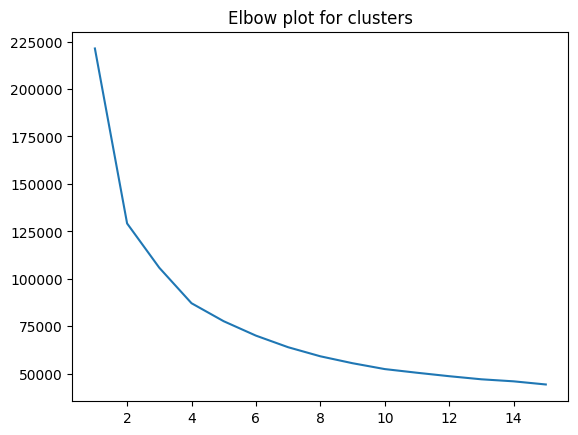

In [ ]:
plt.title('Elbow plot for clusters')
plt.plot(range(1,16), wss);

From the elbow plot, 4 clusters could be a good choice. There is a bend in the curve at that point, suggesting that adding more clusters wouldn't significantly improve the model.

In [ ]:
k_means = KMeans(n_clusters = 4)
k_means.fit(scaled_df)
labels = k_means.labels_

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [ ]:
cric_encode["Clus_kmeans"] = labels
cric_encode.head()

,Match_light_type,Match_format,All_rounder_in_team,First_selection,Opponent,Offshore,Max_run_scored_1over,Max_wicket_taken_1over,Extra_bowls_bowled,Min_run_given_1over,Min_run_scored_1over,Max_run_given_1over,extra_bowls_opponent,Players_scored_zero,player_highest_wicket,Clus_kmeans
0,0,0,3.0,1,6,0,13.0,2,0.0,2,2,6.0,0,2,0,2
1,0,1,4.0,0,8,0,12.0,0,0.0,0,2,6.0,0,1,0,1
2,1,1,2.0,1,8,1,14.0,3,0.0,0,2,6.0,0,2,0,1
3,0,0,2.0,1,3,0,15.0,3,0.0,2,2,6.0,0,2,0,2
4,2,0,3.0,1,6,0,12.0,3,0.0,0,2,6.0,0,2,0,2


We now perform the cluster profiling for our data.

With the help of plots we will see the different patterns in each clusters.

In [ ]:
cric_clus["Clus_kmeans"] = labels
cric_clus.head()

,Result,Match_light_type,Match_format,Bowlers_in_team,All_rounder_in_team,First_selection,Opponent,Season,Audience_number,Offshore,...,Max_wicket_taken_1over,Extra_bowls_bowled,Min_run_given_1over,Min_run_scored_1over,Max_run_given_1over,extra_bowls_opponent,player_highest_run,Players_scored_zero,player_highest_wicket,Clus_kmeans
0,Loss,Day,ODI,3.0,3.0,Bowling,Srilanka,Summer,9940.0,No,...,3,0.0,2,3.0,6.0,0,54.0,3,1,2
1,Win,Day,T20,3.0,4.0,Batting,Zimbabwe,Summer,8400.0,No,...,1,0.0,0,3.0,6.0,0,69.0,2,1,1
2,Loss,Day and Night,T20,3.0,2.0,Bowling,Zimbabwe,Rainy,13146.0,Yes,...,4,0.0,0,3.0,6.0,0,69.0,3,1,1
3,Win,Day,ODI,2.0,2.0,Bowling,Kenya,Summer,7357.0,No,...,4,0.0,2,3.0,6.0,0,73.0,3,1,2
4,Loss,Night,ODI,1.0,3.0,Bowling,Srilanka,Summer,13328.0,No,...,4,0.0,0,3.0,6.0,0,80.0,3,1,2


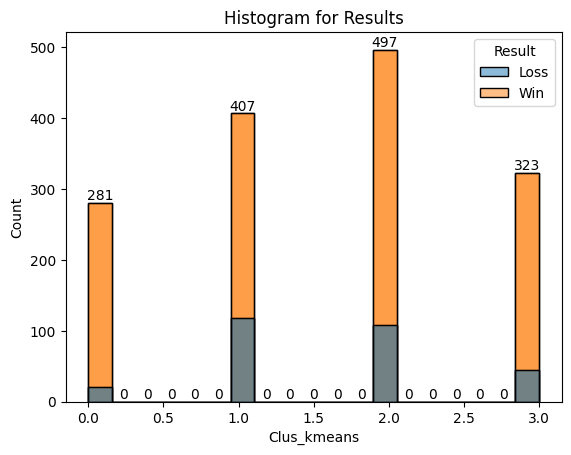

In [ ]:
plt.title('Histogram for Results')
sns.histplot(data = cric_clus, x = 'Clus_kmeans', hue = "Result");
plt.bar_label(sns.histplot(data = cric_clus, x = 'Clus_kmeans', hue = "Result").containers[0],fontsize=10);

In [ ]:
table = pd.crosstab(cric_clus.Clus_kmeans, cric_clus.Result)
table['Total'] = table.sum(axis=1)
print('Crosstab for Cluster and Result')
print(table)

Crosstab for Cluster and Result
Result       Loss  Win  Total
Clus_kmeans                  
0              21  281    302
1             118  407    525
2             108  497    605
3              45  323    368


As seen from above crosstab

 - The number of wins in cluster 3 are more than the other clusters but the win percentage of cluster 2 is better than all the other clusters.
 - Most losses are seen in cluster 0 and then in cluster 2.

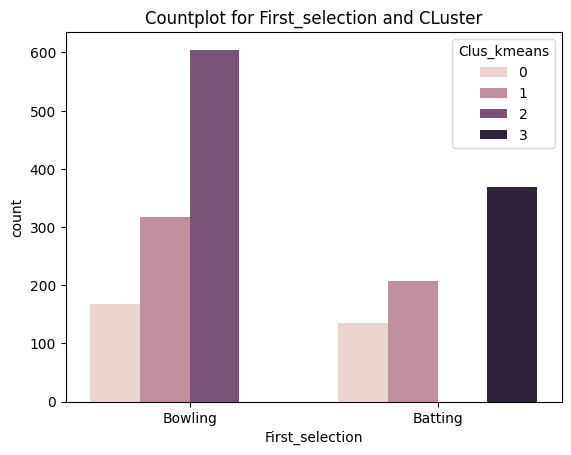

In [ ]:
plt.title('Countplot for First_selection and CLuster')
sns.countplot(data = cric_clus, x='First_selection', hue = 'Clus_kmeans');

In [ ]:
table = pd.crosstab(cric_clus.First_selection, cric_clus.Clus_kmeans)
table['Total'] = table.sum(axis=1)
print('Crosstab for First selction and Cluster')
print(table)

Crosstab for First selction and Cluster
Clus_kmeans        0    1    2    3  Total
First_selection                           
Batting          135  207    0  368    710
Bowling          167  318  605    0   1090


As seen from above crosstab

 - Cluster 3 has the highest number of baating and bowling as first selection.
 - Cluster 1 has the lowest number of baating and bowling as first selection.

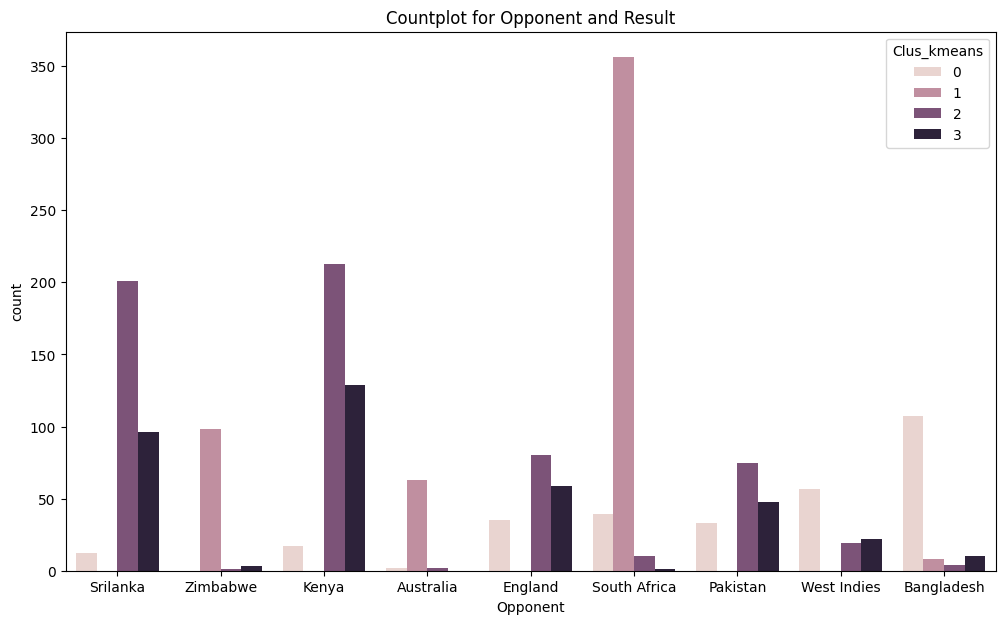

In [ ]:
plt.figure(figsize = (12,7))
plt.title('Countplot for Opponent and Result')
sns.countplot(data = cric_clus, x='Opponent', hue = 'Clus_kmeans');

In [ ]:
table = pd.crosstab(cric_clus.Opponent, cric_clus.Clus_kmeans)
table['Total'] = table.sum(axis=1)
print('Crosstab for Opponent and Cluster')
print(table)

Crosstab for Opponent and Cluster
Clus_kmeans     0    1    2    3  Total
Opponent                               
Australia       2   63    2    0     67
Bangladesh    107    8    4   10    129
England        35    0   80   59    174
Kenya          17    0  213  129    359
Pakistan       33    0   75   48    156
South Africa   39  356   10    1    406
Srilanka       12    0  201   96    309
West Indies    57    0   19   22     98
Zimbabwe        0   98    1    3    102


As seen from above crosstab

 - Most matches against Australia are seen in cluster 0.
 - There are no matches for England, Kenya and West Indies in cluster 0 and also there are no matches for Zimbabwe in cluster 1.
 - Maximum number of matches are seen in cluster 0 which is against South Africa.
 - Cluster 2 and 3 has the maximum number of matches againt Kenya.

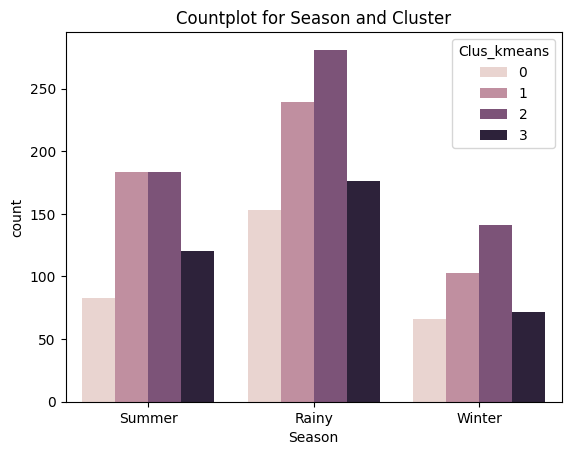

In [ ]:
plt.title('Countplot for Season and Cluster')
sns.countplot(data = cric_clus, x='Season', hue = 'Clus_kmeans');

In [ ]:
table = pd.crosstab(cric_clus.Season, cric_clus.Clus_kmeans)
table['Total'] = table.sum(axis=1)
print('Crosstab for Season and Cluster')
print(table)

Crosstab for Season and Cluster
Clus_kmeans    0    1    2    3  Total
Season                                
Rainy        153  239  281  176    849
Summer        83  183  183  120    569
Winter        66  103  141   72    382


As seen from above crosstab

 - Cluster 3 has the maximum number of matches in the rainy season then followed by cluster 1.
 - Cluster 3 has the maximum number of matches in the summer and winter season.
 - Leat number of matches are observed in cluster 2 for Winter season.

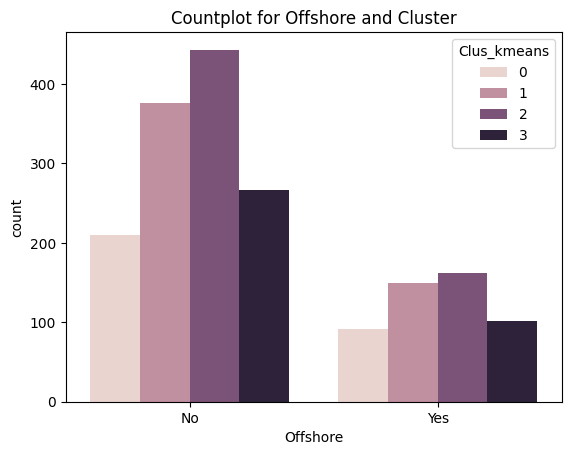

In [ ]:
plt.title('Countplot for Offshore and Cluster')
sns.countplot(data = cric_clus, x='Offshore', hue = 'Clus_kmeans');

In [ ]:
table = pd.crosstab(cric_clus.Offshore, cric_clus.Clus_kmeans)
table['Total'] = table.sum(axis=1)
print('Crosstab for Offshore and Cluster')
print(table)

Crosstab for Offshore and Cluster
Clus_kmeans    0    1    2    3  Total
Offshore                              
No           210  376  443  266   1295
Yes           92  149  162  102    505


As seen from above crosstab

 - Cluster 3 shows the maximum number of matches when offshoe is no.
 - Cluster 2 shows maximum number of matches when offshore is yes.
 - Cluster 2 has no records for matches when offshore is no and cluster 3 has no record of matches when offshore is yes.

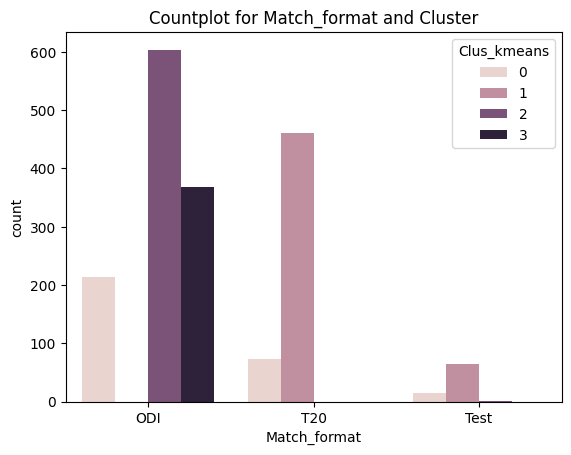

In [ ]:
plt.title('Countplot for Match_format and Cluster')
sns.countplot(data = cric_clus, x='Match_format', hue = 'Clus_kmeans');

In [ ]:
table = pd.crosstab(cric_clus.Match_format, cric_clus.Clus_kmeans)
table['Total'] = table.sum(axis=1)
print('Crosstab for Match_format and Cluster')
print(table)

Crosstab for Match_format and Cluster
Clus_kmeans     0    1    2    3  Total
Match_format                           
ODI           214    0  604  368   1186
T20            73  461    0    0    534
Test           15   64    1    0     80


As seen from above crosstab

 - Maximum number of matches in ODI format are sene in cluster 3 followed by cluster 2.
 - There are no record of matches in cluster 2 and 3 for T20 matches.
 - Most of the T20 and Test matches are seen in cluster 0.


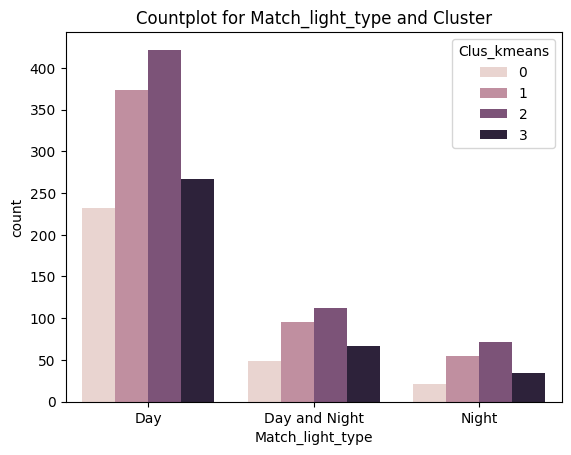

In [ ]:
plt.title('Countplot for Match_light_type and Cluster')
sns.countplot(data = cric_clus, x='Match_light_type', hue = 'Clus_kmeans');

In [ ]:
table = pd.crosstab(cric_clus.Match_light_type, cric_clus.Clus_kmeans)
table['Total'] = table.sum(axis=1)
print('Crosstab for Match_light_type and Cluster')
print(table)

Crosstab for Match_light_type and Cluster
Clus_kmeans         0    1    2    3  Total
Match_light_type                           
Day               232  374  422  267   1295
Day and Night      49   96  112   67    324
Night              21   55   71   34    181


As seen from above crosstab

 - Most number of Day matches are seen in cluster 3 followed by cluster 0.
 - Most number of Day and Night matches are seen in cluster 3 followed by cluster 0.
 - Most number of Night matches are seen in cluster 3 followed by cluster 0.

# Project Note 2

In [ ]:
cric_model = cric_encode

In [ ]:
cric_model.drop(columns = ['Clus_kmeans'], axis = 0, inplace = True)

We will now split the data before starting to build the model.

In [ ]:
X = cric_model
y = cric['Result']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.30, random_state=1)

## Build Decision Tree Model

In [ ]:
dTree = DecisionTreeClassifier(criterion = 'gini', random_state=1)
dTree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

In [ ]:
print(dTree.score(X_train, y_train))
print(dTree.score(X_test, y_test))

1.0
0.8203703703703704


In [ ]:
train_char_label = ['No', 'Yes']
ld_Tree_File = open('ld_Tree_File1.dot','w')
dot_data = tree.export_graphviz(dTree,
                                out_file=ld_Tree_File,
                                feature_names = list(X_train),
                                class_names = list(train_char_label))

ld_Tree_File.close()

In [ ]:
print(pd.DataFrame(dTree.feature_importances_,index= X_train.columns,columns=['imp']).sort_values(by = 'imp',ascending=False))

                             imp
Extra_bowls_bowled      0.130609
Max_run_scored_1over    0.093458
Players_scored_zero     0.089837
Max_wicket_taken_1over  0.088543
extra_bowls_opponent    0.081820
Min_run_given_1over     0.081612
player_highest_wicket   0.077111
Offshore                0.073148
Opponent                0.068698
All_rounder_in_team     0.066037
Max_run_given_1over     0.044202
Min_run_scored_1over    0.043610
Match_light_type        0.039423
First_selection         0.016384
Match_format            0.005509


In [ ]:
reg_dt_model = DecisionTreeClassifier(criterion='gini', max_depth=10,min_samples_leaf=30,min_samples_split=300)
reg_dt_model.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=10, min_samples_leaf=30, min_samples_split=300)

In [ ]:
ld_tree_regularized = open('ld_tree_regularized.dot2','w')
dot_data = tree.export_graphviz(reg_dt_model, out_file= ld_tree_regularized , feature_names = list(X_train), class_names = list(train_char_label))

ld_tree_regularized.close()
dot_data

In [ ]:
print (pd.DataFrame(reg_dt_model.feature_importances_, columns = ["Imp"], index = X_train.columns).sort_values('Imp',ascending=False))

                             Imp
Offshore                0.439086
player_highest_wicket   0.360382
Extra_bowls_bowled      0.109298
Min_run_scored_1over    0.053902
All_rounder_in_team     0.028094
Max_run_scored_1over    0.009237
Match_light_type        0.000000
Match_format            0.000000
First_selection         0.000000
Opponent                0.000000
Max_wicket_taken_1over  0.000000
Min_run_given_1over     0.000000
Max_run_given_1over     0.000000
extra_bowls_opponent    0.000000
Players_scored_zero     0.000000


In [ ]:
ytrain_predict = reg_dt_model.predict(X_train)
ytest_predict = reg_dt_model.predict(X_test)

In [ ]:
ytest_predict_prob=reg_dt_model.predict_proba(X_test)
ytest_predict_prob

array([[0.12352941, 0.87647059],
       [0.0745614 , 0.9254386 ],
       [0.04954955, 0.95045045],
       ...,
       [0.12352941, 0.87647059],
       [0.24      , 0.76      ],
       [0.24      , 0.76      ]])

In [ ]:
 pd.DataFrame(ytest_predict_prob).head()

,0,1
0,0.123529,0.876471
1,0.074561,0.925439
2,0.049550,0.950450
3,0.180995,0.819005
4,0.011696,0.988304


In [ ]:
from sklearn.metrics import confusion_matrix,classification_report

In [ ]:
confusion_matrix(y_train, ytrain_predict)

array([[  67,  123],
       [  60, 1010]])

In [ ]:
reg_dt_model.score(X_train,y_train)

0.8547619047619047

In [ ]:
print(classification_report(y_train, ytrain_predict))

              precision    recall  f1-score   support

           0       0.53      0.35      0.42       190
           1       0.89      0.94      0.92      1070

    accuracy                           0.85      1260
   macro avg       0.71      0.65      0.67      1260
weighted avg       0.84      0.85      0.84      1260



AUC: 0.784


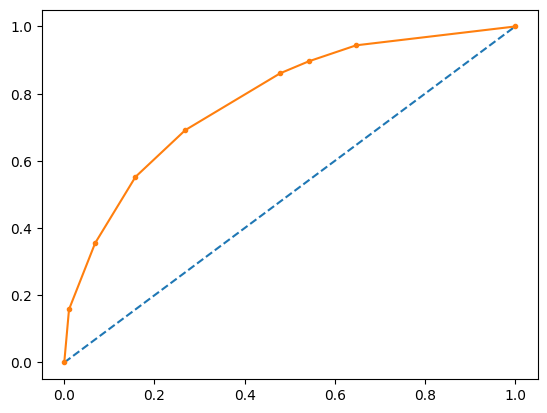

In [ ]:
# predict probabilities
probs = reg_dt_model.predict_proba(X_train)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_train, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_train, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
# show the plot
plt.show()

In [ ]:
confusion_matrix(y_test, ytest_predict)

array([[ 31,  71],
       [ 29, 409]])

In [ ]:
print(classification_report(y_test, ytest_predict))

              precision    recall  f1-score   support

           0       0.52      0.30      0.38       102
           1       0.85      0.93      0.89       438

    accuracy                           0.81       540
   macro avg       0.68      0.62      0.64       540
weighted avg       0.79      0.81      0.80       540



AUC: 0.699


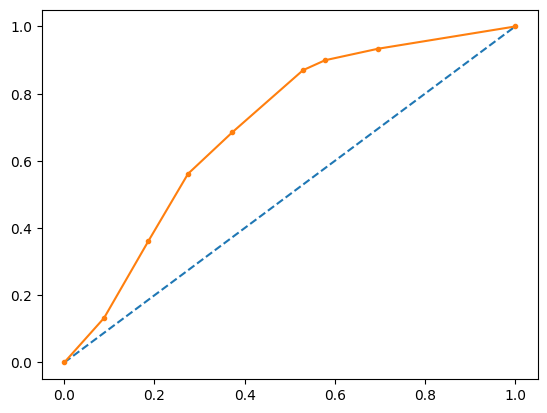

In [ ]:
# predict probabilities
probs = reg_dt_model.predict_proba(X_test)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_test, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
# show the plot
plt.show()

## Random forest classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rfcl = RandomForestClassifier(n_estimators = 100,max_features=7,random_state=0)
rfcl = rfcl.fit(X_train, y_train)

In [ ]:
ytrain_predict = rfcl.predict(X_train)
ytest_predict = rfcl.predict(X_test)

In [ ]:
rfcl.score(X_train,y_train)

1.0

In [ ]:
rfcl.score(X_test,y_test)

0.8648148148148148

In [ ]:
confusion_matrix(y_train,ytrain_predict)

array([[ 190,    0],
       [   0, 1070]])

In [ ]:
print(classification_report(y_train, ytrain_predict))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       190
           1       1.00      1.00      1.00      1070

    accuracy                           1.00      1260
   macro avg       1.00      1.00      1.00      1260
weighted avg       1.00      1.00      1.00      1260



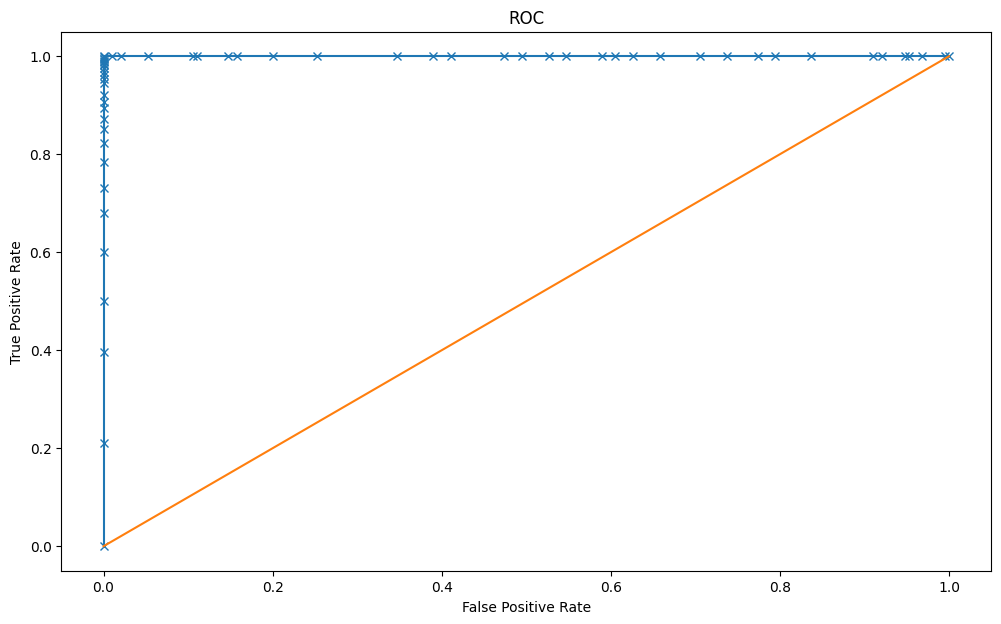

Area under Curve is 1.0


In [ ]:
rf_fpr, rf_tpr,_=roc_curve(y_train,rfcl.predict_proba(X_train)[:,1])
plt.figure(figsize=(12,7))
plt.plot(rf_fpr,rf_tpr, marker='x', label='Random Forest')
plt.plot(np.arange(0,1.1,0.1),np.arange(0,1.1,0.1))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC')
plt.show()
print('Area under Curve is', roc_auc_score(y_train,rfcl.predict_proba(X_train)[:,1]))

In [ ]:
confusion_matrix(y_test,ytest_predict)

array([[ 40,  62],
       [ 11, 427]])

In [ ]:
print(classification_report(y_test, ytest_predict))

              precision    recall  f1-score   support

           0       0.78      0.39      0.52       102
           1       0.87      0.97      0.92       438

    accuracy                           0.86       540
   macro avg       0.83      0.68      0.72       540
weighted avg       0.86      0.86      0.85       540



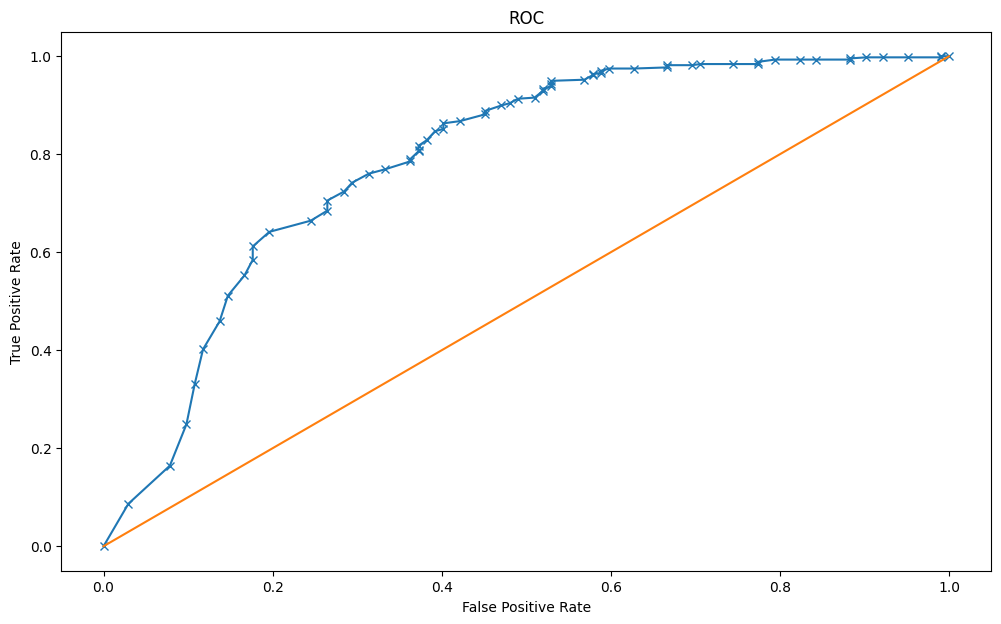

Area under Curve is 0.7880629420718059


In [ ]:
rf_fpr, rf_tpr,_=roc_curve(y_test,rfcl.predict_proba(X_test)[:,1])
plt.figure(figsize=(12,7))
plt.plot(rf_fpr,rf_tpr, marker='x', label='Random Forest')
plt.plot(np.arange(0,1.1,0.1),np.arange(0,1.1,0.1))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC')
plt.show()
print('Area under Curve is', roc_auc_score(y_test,rfcl.predict_proba(X_test)[:,1]))

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [5,7,10],
    'max_features': [6,7,8],
    'min_samples_leaf': [30,60,90],
    'min_samples_split': [90,180,270],
    'n_estimators': [100,200,300]
}

rfcl = RandomForestClassifier(random_state=0)

grid_search = GridSearchCV(estimator = rfcl, param_grid = param_grid, cv = 10)

In [ ]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=10, estimator=RandomForestClassifier(random_state=0),
             param_grid={'max_depth': [5, 7, 10], 'max_features': [6, 7, 8],
                         'min_samples_leaf': [30, 60, 90],
                         'min_samples_split': [90, 180, 270],
                         'n_estimators': [100, 200, 300]})

In [ ]:
grid_search.best_params_

{'max_depth': 5,
 'max_features': 8,
 'min_samples_leaf': 30,
 'min_samples_split': 90,
 'n_estimators': 200}

In [ ]:
best_grid_ran = grid_search.best_estimator_

In [ ]:
best_grid_ran

RandomForestClassifier(max_depth=5, max_features=8, min_samples_leaf=30,
                       min_samples_split=90, n_estimators=200, random_state=0)

In [ ]:
ytrain_predict = best_grid_ran.predict(X_train)
ytest_predict = best_grid_ran.predict(X_test)

In [ ]:
confusion_matrix(y_train,ytrain_predict)

array([[  17,  173],
       [   2, 1068]])

In [ ]:
print(classification_report(y_train,ytrain_predict))

              precision    recall  f1-score   support

           0       0.89      0.09      0.16       190
           1       0.86      1.00      0.92      1070

    accuracy                           0.86      1260
   macro avg       0.88      0.54      0.54      1260
weighted avg       0.87      0.86      0.81      1260



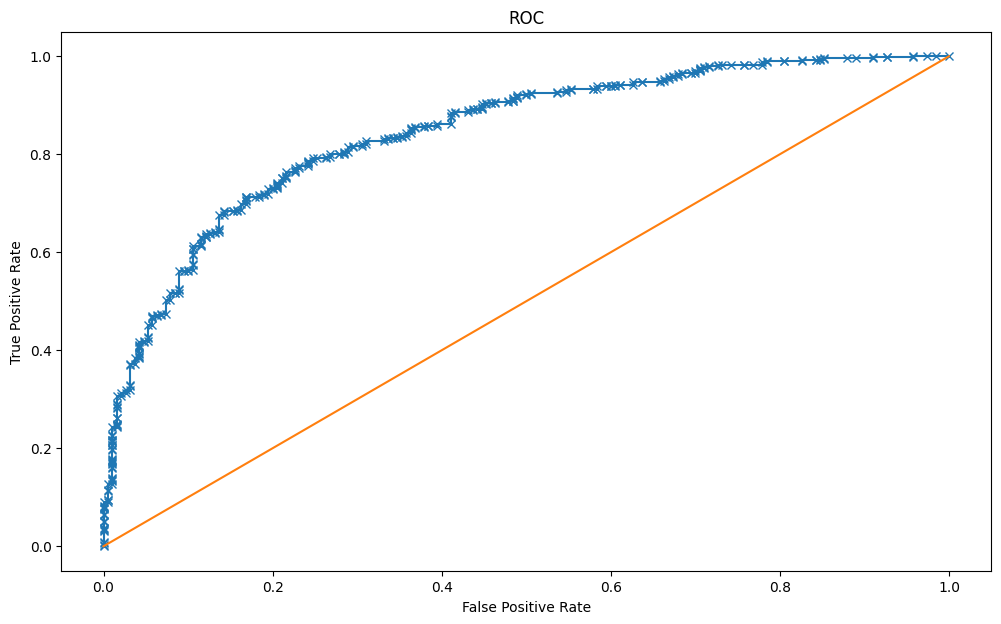

Area under Curve is 0.8443138219380226


In [ ]:
rf_fpr, rf_tpr,_=roc_curve(y_train,best_grid_ran.predict_proba(X_train)[:,1])
plt.figure(figsize=(12,7))
plt.plot(rf_fpr,rf_tpr, marker='x', label='Random Forest')
plt.plot(np.arange(0,1.1,0.1),np.arange(0,1.1,0.1))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC')
plt.show()
print('Area under Curve is', roc_auc_score(y_train,best_grid_ran.predict_proba(X_train)[:,1]))

In [ ]:
confusion_matrix(y_test,ytest_predict)

array([[  9,  93],
       [  5, 433]])

In [ ]:
print(classification_report(y_test,ytest_predict))

              precision    recall  f1-score   support

           0       0.64      0.09      0.16       102
           1       0.82      0.99      0.90       438

    accuracy                           0.82       540
   macro avg       0.73      0.54      0.53       540
weighted avg       0.79      0.82      0.76       540



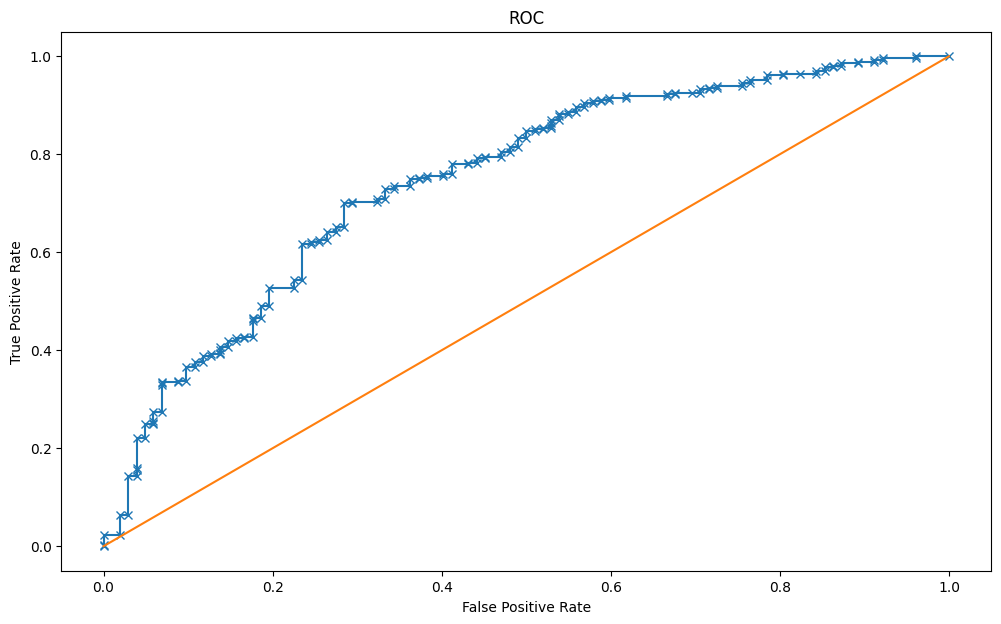

Area under Curve is 0.7470453934998657


In [ ]:
rf_fpr, rf_tpr,_=roc_curve(y_test,best_grid_ran.predict_proba(X_test)[:,1])
plt.figure(figsize=(12,7))
plt.plot(rf_fpr,rf_tpr, marker='x', label='Random Forest')
plt.plot(np.arange(0,1.1,0.1),np.arange(0,1.1,0.1))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC')
plt.show()
print('Area under Curve is', roc_auc_score(y_test,best_grid_ran.predict_proba(X_test)[:,1]))

## Adaboost

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn import metrics

In [ ]:
ADB_model = AdaBoostClassifier(n_estimators=100,random_state=1)
ADB_model.fit(X_train,y_train)

AdaBoostClassifier(n_estimators=100, random_state=1)

In [ ]:
## Performance Matrix on train data set
y_train_predict = ADB_model.predict(X_train)
model_score = ADB_model.score(X_train, y_train)
print(model_score)
print(metrics.confusion_matrix(y_train, y_train_predict))
print(metrics.classification_report(y_train, y_train_predict))

0.8928571428571429
[[  79  111]
 [  24 1046]]
              precision    recall  f1-score   support

           0       0.77      0.42      0.54       190
           1       0.90      0.98      0.94      1070

    accuracy                           0.89      1260
   macro avg       0.84      0.70      0.74      1260
weighted avg       0.88      0.89      0.88      1260



AUC: 0.902


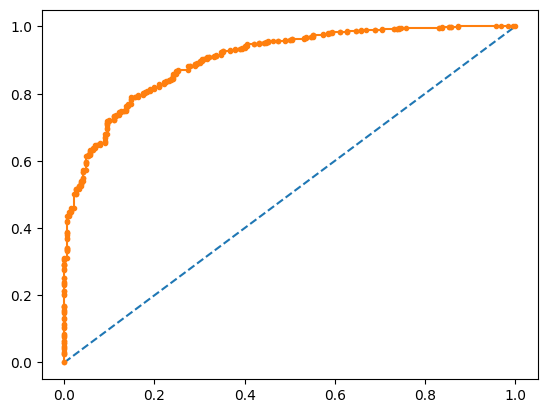

In [ ]:
# predict probabilities
probs = ADB_model.predict_proba(X_train)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
auc = roc_auc_score(y_train, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
fpr, tpr, thresholds = roc_curve(y_train, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
# show the plot
plt.show()

In [ ]:
## Performance Matrix on test data set
y_test_predict = ADB_model.predict(X_test)
model_score = ADB_model.score(X_test, y_test)
print(model_score)
print(metrics.confusion_matrix(y_test, y_test_predict))
print(metrics.classification_report(y_test, y_test_predict))

0.8444444444444444
[[ 31  71]
 [ 13 425]]
              precision    recall  f1-score   support

           0       0.70      0.30      0.42       102
           1       0.86      0.97      0.91       438

    accuracy                           0.84       540
   macro avg       0.78      0.64      0.67       540
weighted avg       0.83      0.84      0.82       540



AUC: 0.754


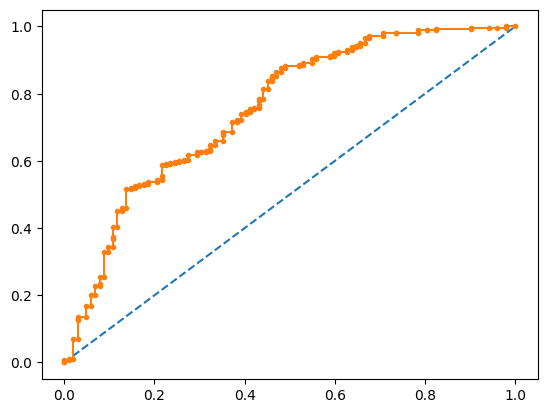

In [ ]:
# predict probabilities
probs = ADB_model.predict_proba(X_test)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
auc = roc_auc_score(y_test, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
fpr, tpr, thresholds = roc_curve(y_test, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
# show the plot
plt.show()

## KNN model

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
KNN_model=KNeighborsClassifier()
KNN_model.fit(X_train,y_train)

KNeighborsClassifier()

In [ ]:
## Performance Matrix on train data set
y_train_predict = KNN_model.predict(X_train)
model_score = KNN_model.score(X_train, y_train)
print(model_score)
print(metrics.confusion_matrix(y_train, y_train_predict))
print(metrics.classification_report(y_train, y_train_predict))

0.873015873015873
[[  50  140]
 [  20 1050]]
              precision    recall  f1-score   support

           0       0.71      0.26      0.38       190
           1       0.88      0.98      0.93      1070

    accuracy                           0.87      1260
   macro avg       0.80      0.62      0.66      1260
weighted avg       0.86      0.87      0.85      1260



AUC: 0.907


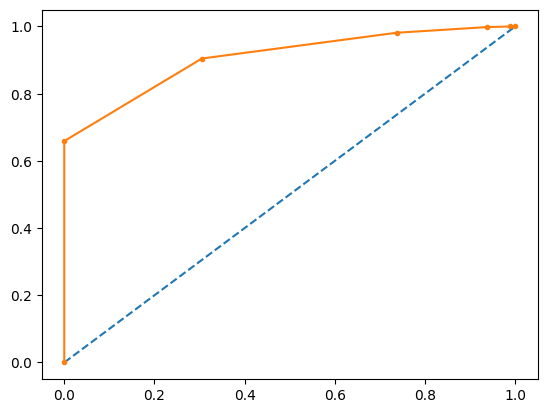

In [ ]:
# predict probabilities
probs = KNN_model.predict_proba(X_train)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
auc = roc_auc_score(y_train, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
fpr, tpr, thresholds = roc_curve(y_train, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
# show the plot
plt.show()

In [ ]:
## Performance Matrix on test data set
y_test_predict = KNN_model.predict(X_test)
model_score = KNN_model.score(X_test, y_test)
print(model_score)
print(metrics.confusion_matrix(y_test, y_test_predict))
print(metrics.classification_report(y_test, y_test_predict))

0.8148148148148148
[[ 12  90]
 [ 10 428]]
              precision    recall  f1-score   support

           0       0.55      0.12      0.19       102
           1       0.83      0.98      0.90       438

    accuracy                           0.81       540
   macro avg       0.69      0.55      0.54       540
weighted avg       0.77      0.81      0.76       540



AUC: 0.666


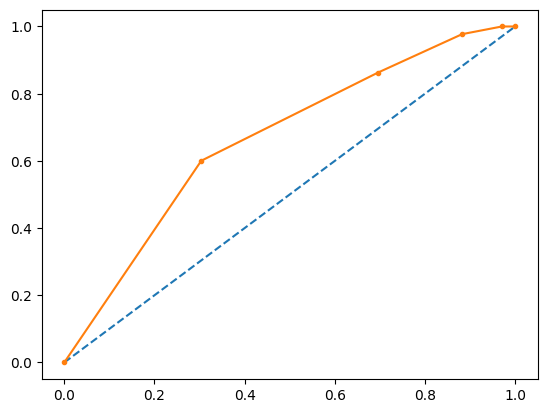

In [ ]:
# predict probabilities
probs = KNN_model.predict_proba(X_test)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
auc = roc_auc_score(y_test, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
fpr, tpr, thresholds = roc_curve(y_test, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
# show the plot
plt.show()

## Naive Bayes Model

In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
NB_model = GaussianNB()
NB_model.fit(X_train, y_train)

GaussianNB()

In [ ]:
## Performance Matrix on train data set
y_train_predict = NB_model.predict(X_train)
model_score = NB_model.score(X_train, y_train)
print(model_score)
print(metrics.confusion_matrix(y_train, y_train_predict))
print(metrics.classification_report(y_train, y_train_predict))

0.8714285714285714
[[  87  103]
 [  59 1011]]
              precision    recall  f1-score   support

           0       0.60      0.46      0.52       190
           1       0.91      0.94      0.93      1070

    accuracy                           0.87      1260
   macro avg       0.75      0.70      0.72      1260
weighted avg       0.86      0.87      0.86      1260



AUC: 0.798


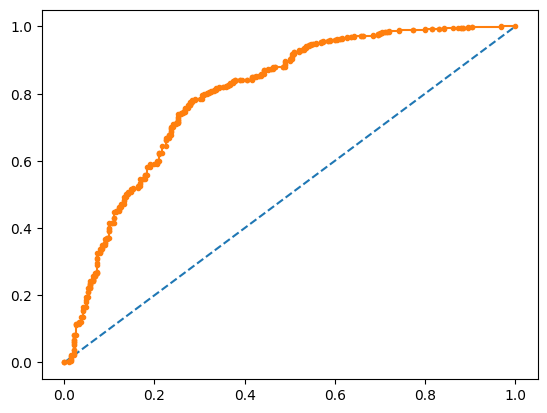

In [ ]:
# predict probabilities
probs = NB_model.predict_proba(X_train)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
auc = roc_auc_score(y_train, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
fpr, tpr, thresholds = roc_curve(y_train, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
# show the plot
plt.show()

In [ ]:
## Performance Matrix on test data set
y_test_predict = NB_model.predict(X_test)
model_score = NB_model.score(X_test, y_test)
print(model_score)
print(metrics.confusion_matrix(y_test, y_test_predict))
print(metrics.classification_report(y_test, y_test_predict))

0.8240740740740741
[[ 33  69]
 [ 26 412]]
              precision    recall  f1-score   support

           0       0.56      0.32      0.41       102
           1       0.86      0.94      0.90       438

    accuracy                           0.82       540
   macro avg       0.71      0.63      0.65       540
weighted avg       0.80      0.82      0.80       540



AUC: 0.732


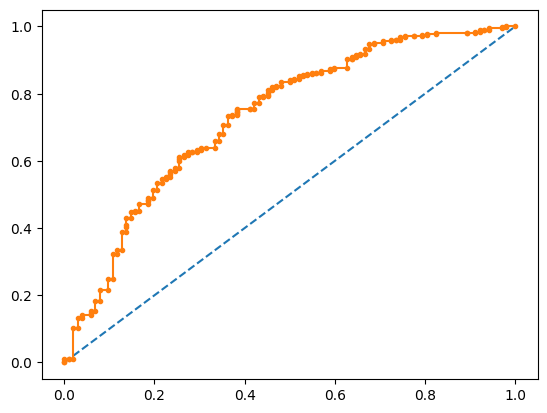

In [ ]:
# predict probabilities
probs = NB_model.predict_proba(X_test)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
auc = roc_auc_score(y_test, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
fpr, tpr, thresholds = roc_curve(y_test, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
# show the plot
plt.show()

## XGBoost

In [ ]:
from xgboost import XGBClassifier

In [ ]:
xgb = XGBClassifier(random_state=1,enable_categorical=True)
xgb.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=1, ...)

In [ ]:
## Performance Matrix on train data set
y_train_predict = xgb.predict(X_train)
model_score = xgb.score(X_train, y_train)
print(model_score)
print(metrics.confusion_matrix(y_train, y_train_predict))
print(metrics.classification_report(y_train, y_train_predict))

1.0
[[ 190    0]
 [   0 1070]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       190
           1       1.00      1.00      1.00      1070

    accuracy                           1.00      1260
   macro avg       1.00      1.00      1.00      1260
weighted avg       1.00      1.00      1.00      1260



AUC: 1.000


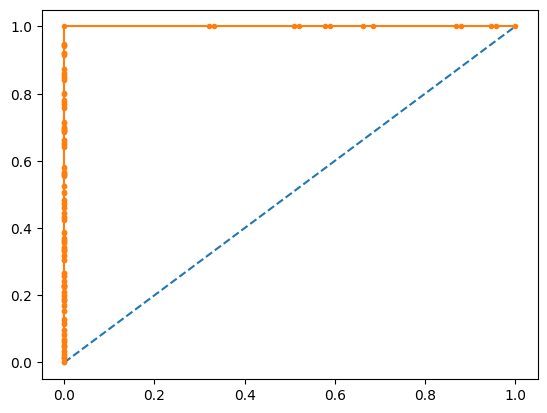

In [ ]:
# predict probabilities
probs = xgb.predict_proba(X_train)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
auc = roc_auc_score(y_train, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
fpr, tpr, thresholds = roc_curve(y_train, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
# show the plot
plt.show()

In [ ]:
## Performance Matrix on test data set
y_test_predict = xgb.predict(X_test)
model_score = xgb.score(X_test, y_test)
print(model_score)
print(metrics.confusion_matrix(y_test, y_test_predict))
print(metrics.classification_report(y_test, y_test_predict))

0.8685185185185185
[[ 49  53]
 [ 18 420]]
              precision    recall  f1-score   support

           0       0.73      0.48      0.58       102
           1       0.89      0.96      0.92       438

    accuracy                           0.87       540
   macro avg       0.81      0.72      0.75       540
weighted avg       0.86      0.87      0.86       540



AUC: 0.769


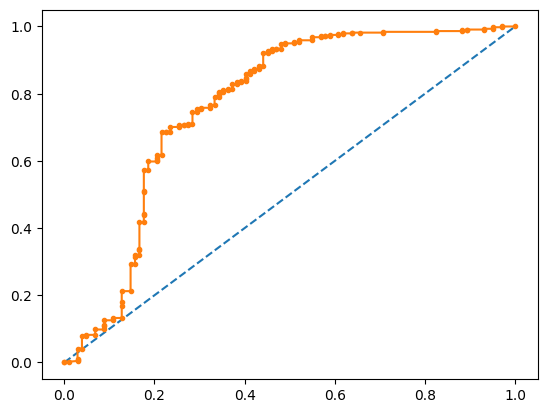

In [ ]:
# predict probabilities
probs = xgb.predict_proba(X_test)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
auc = roc_auc_score(y_test, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
fpr, tpr, thresholds = roc_curve(y_test, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
# show the plot
plt.show()

## Comparing models

In [ ]:
from sklearn.metrics import f1_score
##  Function to calculate different metric scores of the model - Accuracy, Recall and Precision
def get_metrics_score(model,flag=True):
    '''
    model : classifier to predict values of X

    '''
    # defining an empty list to store train and test results
    score_list=[]

    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    train_acc = model.score(X_train,y_train)
    test_acc = model.score(X_test,y_test)

    train_recall = metrics.recall_score(y_train,pred_train)
    test_recall = metrics.recall_score(y_test,pred_test)

    train_precision = metrics.precision_score(y_train,pred_train)
    test_precision = metrics.precision_score(y_test,pred_test)

    train_f1 = f1_score(y_train, pred_train)
    test_f1 = f1_score(y_test, pred_test)

    score_list.extend((train_acc,test_acc,train_recall,test_recall,train_precision,test_precision,train_f1,test_f1))

    # If the flag is set to True then only the following print statements will be dispayed. The default value is set to True.
    if flag == True:
        print("Accuracy on training set : ",model.score(X_train,y_train))
        print("Accuracy on test set : ",model.score(X_test,y_test))
        print("Recall on training set : ",metrics.recall_score(y_train,pred_train))
        print("Recall on test set : ",metrics.recall_score(y_test,pred_test))
        print("Precision on training set : ",metrics.precision_score(y_train,pred_train))
        print("Precision on test set : ",metrics.precision_score(y_test,pred_test))
        print("f1score on training set : ",f1_score(y_train, pred_train))
        print("f1score on test set : ",f1_score(y_test, pred_test))


    return score_list # returning the list with train and test scores

In [ ]:
# defining list of models
models = [dTree, best_grid_ran, ADB_model, KNN_model, NB_model, xgb]

# defining empty lists to add train and test results
acc_train = []
acc_test = []
recall_train = []
recall_test = []
precision_train = []
precision_test = []
f1_train = []
f1_test = []

# looping through all the models to get the accuracy, precall and precision scores
for model in models:
    j = get_metrics_score(model,False)
    acc_train.append(np.round(j[0],2))
    acc_test.append(np.round(j[1],2))
    recall_train.append(np.round(j[2],2))
    recall_test.append(np.round(j[3],2))
    precision_train.append(np.round(j[4],2))
    precision_test.append(np.round(j[5],2))
    f1_train.append(np.round(j[6],2))
    f1_test.append(np.round(j[7],2))

In [ ]:
comparison_frame = pd.DataFrame({'Model':['Decision Tree','Random forest with grid search CV',
                                          'Adaboost','KNN model',
                                          'Naive Bayes model','XGBoost with default parameters'],
                                          'Train_Accuracy': acc_train,'Test_Accuracy': acc_test,
                                          'Train_Recall':recall_train,'Test_Recall':recall_test,
                                          'Train_Precision':precision_train,'Test_Precision':precision_test,
                                          'Train_f1score':f1_train,'Test_f1score':f1_test})
comparison_frame

,Model,Train_Accuracy,Test_Accuracy,Train_Recall,Test_Recall,Train_Precision,Test_Precision,Train_f1score,Test_f1score
0,Decision Tree,1.00,0.82,1.00,0.90,1.00,0.88,1.00,0.89
1,Random forest with grid search CV,0.86,0.82,1.00,0.99,0.86,0.82,0.92,0.90
2,Adaboost,0.89,0.84,0.98,0.97,0.90,0.86,0.94,0.91
3,KNN model,0.87,0.81,0.98,0.98,0.88,0.83,0.93,0.90
4,Naive Bayes model,0.87,0.82,0.94,0.94,0.91,0.86,0.93,0.90
5,XGBoost with default parameters,1.00,0.87,1.00,0.96,1.00,0.89,1.00,0.92


As seen above we can say that Random forest with grid search CV,Adaboost, KNN model and Naive Bayes have the f1score less than 1 which indicates that these models are not over fit.

Decision Tree and XG boost on the other hand have an f1 score of 1 for the train data indicating that the model could be overfit.

We can say that Random forest with grid search CV can be considered as the best performing model as it shows a good balance between training and testing performance (test accuracy: 0.82, test F1 score: 0.90).

## Model building after SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
cric_model['Result'] = cric['Result']

In [ ]:
X = cric_model.drop(columns = ['Result'],axis = 0)
y = cric_model['Result']

In [ ]:
sm = SMOTE(random_state=2)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train.ravel())

In [ ]:
## Let's check the shape after SMOTE
X_train_res.shape

(2140, 15)

In [ ]:
X_train_res.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2140 entries, 0 to 2139
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   Match_light_type        2140 non-null   int64   
 1   Match_format            2140 non-null   int64   
 2   All_rounder_in_team     1615 non-null   category
 3   First_selection         2140 non-null   int64   
 4   Opponent                2140 non-null   int64   
 5   Offshore                2140 non-null   int64   
 6   Max_run_scored_1over    2140 non-null   float64 
 7   Max_wicket_taken_1over  2140 non-null   int64   
 8   Extra_bowls_bowled      2140 non-null   float64 
 9   Min_run_given_1over     2140 non-null   int64   
 10  Min_run_scored_1over    2140 non-null   int64   
 11  Max_run_given_1over     2140 non-null   float64 
 12  extra_bowls_opponent    2140 non-null   int64   
 13  Players_scored_zero     2140 non-null   int64   
 14  player_highest_wicket   

In [ ]:
X_train_res['All_rounder_in_team'].fillna(X_train_res['All_rounder_in_team'].mode()[0], inplace=True)

In [ ]:
X_train_res.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2140 entries, 0 to 2139
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   Match_light_type        2140 non-null   int64   
 1   Match_format            2140 non-null   int64   
 2   All_rounder_in_team     2140 non-null   category
 3   First_selection         2140 non-null   int64   
 4   Opponent                2140 non-null   int64   
 5   Offshore                2140 non-null   int64   
 6   Max_run_scored_1over    2140 non-null   float64 
 7   Max_wicket_taken_1over  2140 non-null   int64   
 8   Extra_bowls_bowled      2140 non-null   float64 
 9   Min_run_given_1over     2140 non-null   int64   
 10  Min_run_scored_1over    2140 non-null   int64   
 11  Max_run_given_1over     2140 non-null   float64 
 12  extra_bowls_opponent    2140 non-null   int64   
 13  Players_scored_zero     2140 non-null   int64   
 14  player_highest_wicket   

## Decision tree after SMOTE

In [ ]:
dTree_smote = DecisionTreeClassifier(criterion = 'gini', random_state=1)
dTree_smote.fit(X_train_res, y_train_res)

DecisionTreeClassifier(random_state=1)

In [ ]:
print(dTree_smote.score(X_train_res, y_train_res))
print(dTree_smote.score(X_test, y_test))

1.0
0.7944444444444444


In [ ]:
train_char_label = ['No', 'Yes']
ld_Tree_File = open('ld_Tree_File1.dot','w')
dot_data = tree.export_graphviz(dTree_smote,
                                out_file=ld_Tree_File,
                                feature_names = list(X_train_res),
                                class_names = list(train_char_label))

ld_Tree_File.close()

In [ ]:
print(pd.DataFrame(dTree_smote.feature_importances_,index= X_train_res.columns,columns=['imp']).sort_values(by = 'imp',ascending=False))

                             imp
Extra_bowls_bowled      0.141688
player_highest_wicket   0.120793
Max_run_scored_1over    0.120607
Min_run_given_1over     0.103120
All_rounder_in_team     0.077522
Max_wicket_taken_1over  0.071192
extra_bowls_opponent    0.060904
Min_run_scored_1over    0.058685
Opponent                0.055048
Max_run_given_1over     0.044762
Players_scored_zero     0.039710
Match_light_type        0.034113
Offshore                0.028930
Match_format            0.021648
First_selection         0.021278


In [ ]:
reg_dt_model = DecisionTreeClassifier(criterion='gini', max_depth=10,min_samples_leaf=30,min_samples_split=300)
reg_dt_model.fit(X_train_res,y_train_res)

DecisionTreeClassifier(max_depth=10, min_samples_leaf=30, min_samples_split=300)

In [ ]:
ld_tree_regularized = open('ld_tree_regularized.dot2','w')
dot_data = tree.export_graphviz(reg_dt_model, out_file= ld_tree_regularized , feature_names = list(X_train_res), class_names = list(train_char_label))

ld_tree_regularized.close()
dot_data

In [ ]:
print (pd.DataFrame(reg_dt_model.feature_importances_, columns = ["Imp"], index = X_train_res.columns).sort_values('Imp',ascending=False))

                             Imp
player_highest_wicket   0.368900
Min_run_given_1over     0.257990
Max_wicket_taken_1over  0.115218
Min_run_scored_1over    0.112878
Players_scored_zero     0.051099
Match_format            0.037671
Max_run_given_1over     0.031038
All_rounder_in_team     0.020707
Match_light_type        0.004500
First_selection         0.000000
Opponent                0.000000
Offshore                0.000000
Max_run_scored_1over    0.000000
Extra_bowls_bowled      0.000000
extra_bowls_opponent    0.000000


In [ ]:
ytrain_predict = reg_dt_model.predict(X_train_res)
ytest_predict = reg_dt_model.predict(X_test)

In [ ]:
ytest_predict_prob=reg_dt_model.predict_proba(X_test)
ytest_predict_prob

array([[0.67808219, 0.32191781],
       [0.3483871 , 0.6516129 ],
       [0.03636364, 0.96363636],
       ...,
       [0.03636364, 0.96363636],
       [0.25503356, 0.74496644],
       [0.68619247, 0.31380753]])

In [ ]:
 pd.DataFrame(ytest_predict_prob).head()

,0,1
0,0.678082,0.321918
1,0.348387,0.651613
2,0.036364,0.963636
3,0.036364,0.963636
4,0.294326,0.705674


In [ ]:
print(classification_report(y_train_res, ytrain_predict))

              precision    recall  f1-score   support

           0       0.71      0.81      0.76      1070
           1       0.78      0.67      0.72      1070

    accuracy                           0.74      2140
   macro avg       0.75      0.74      0.74      2140
weighted avg       0.75      0.74      0.74      2140



AUC: 0.815


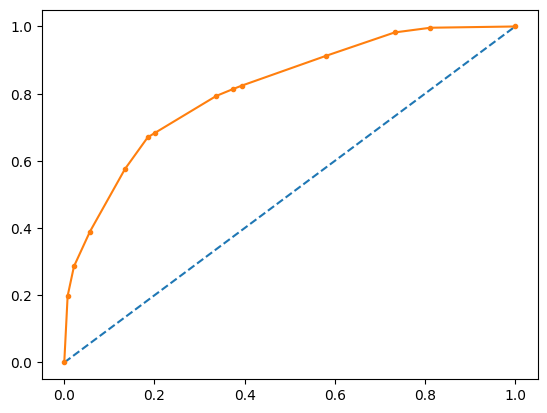

In [ ]:
# predict probabilities
probs = reg_dt_model.predict_proba(X_train_res)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
auc = roc_auc_score(y_train_res, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
fpr, tpr, thresholds = roc_curve(y_train_res, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
# show the plot
plt.show()

In [ ]:
print(classification_report(y_test, ytest_predict))

              precision    recall  f1-score   support

           0       0.28      0.52      0.36       102
           1       0.86      0.68      0.76       438

    accuracy                           0.65       540
   macro avg       0.57      0.60      0.56       540
weighted avg       0.75      0.65      0.69       540



AUC: 0.668


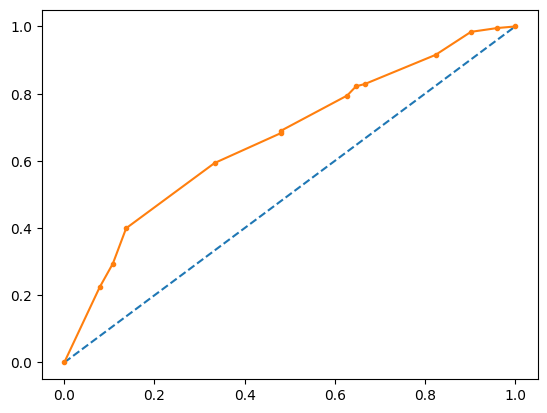

In [ ]:
# predict probabilities
probs = reg_dt_model.predict_proba(X_test)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_test, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
# show the plot
plt.show()

## Random Forest Classifier after smote

In [ ]:
rfcl_smote = RandomForestClassifier(n_estimators = 100,max_features=7,random_state=0)
rfcl_smote = rfcl_smote.fit(X_train_res, y_train_res)

In [ ]:
ytrain_predict = rfcl_smote.predict(X_train_res)
ytest_predict = rfcl_smote.predict(X_test)

In [ ]:
print(classification_report(y_train_res, ytrain_predict))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1070
           1       1.00      1.00      1.00      1070

    accuracy                           1.00      2140
   macro avg       1.00      1.00      1.00      2140
weighted avg       1.00      1.00      1.00      2140



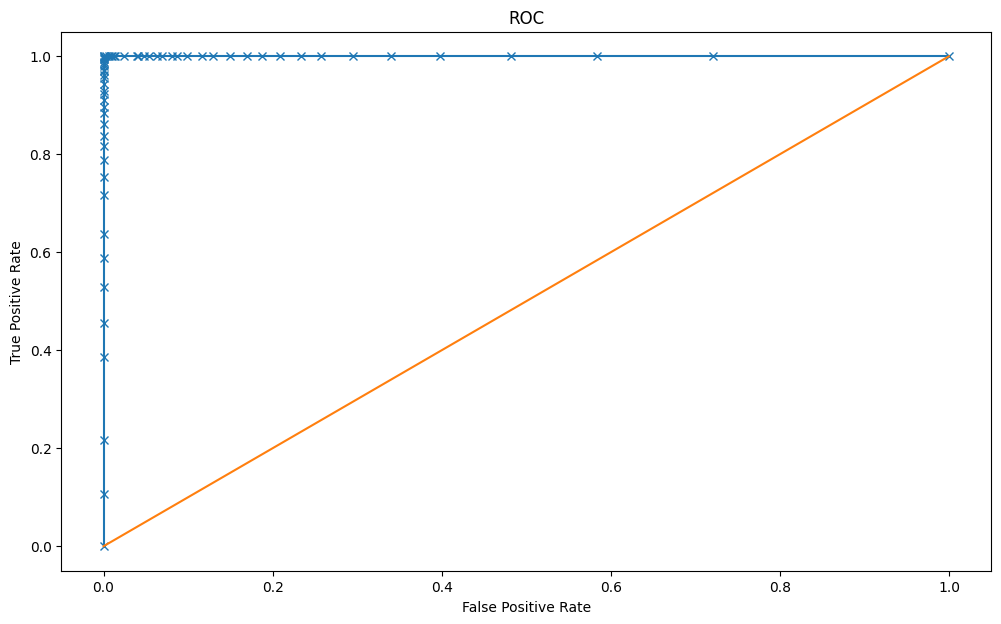

Area under Curve is 1.0


In [ ]:
rf_fpr, rf_tpr,_=roc_curve(y_train_res,rfcl_smote.predict_proba(X_train_res)[:,1])
plt.figure(figsize=(12,7))
plt.plot(rf_fpr,rf_tpr, marker='x', label='Random Forest')
plt.plot(np.arange(0,1.1,0.1),np.arange(0,1.1,0.1))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC')
plt.show()
print('Area under Curve is', roc_auc_score(y_train_res,rfcl_smote.predict_proba(X_train_res)[:,1]))

In [ ]:
print(classification_report(y_test, ytest_predict))

              precision    recall  f1-score   support

           0       0.63      0.48      0.54       102
           1       0.89      0.93      0.91       438

    accuracy                           0.85       540
   macro avg       0.76      0.71      0.73       540
weighted avg       0.84      0.85      0.84       540



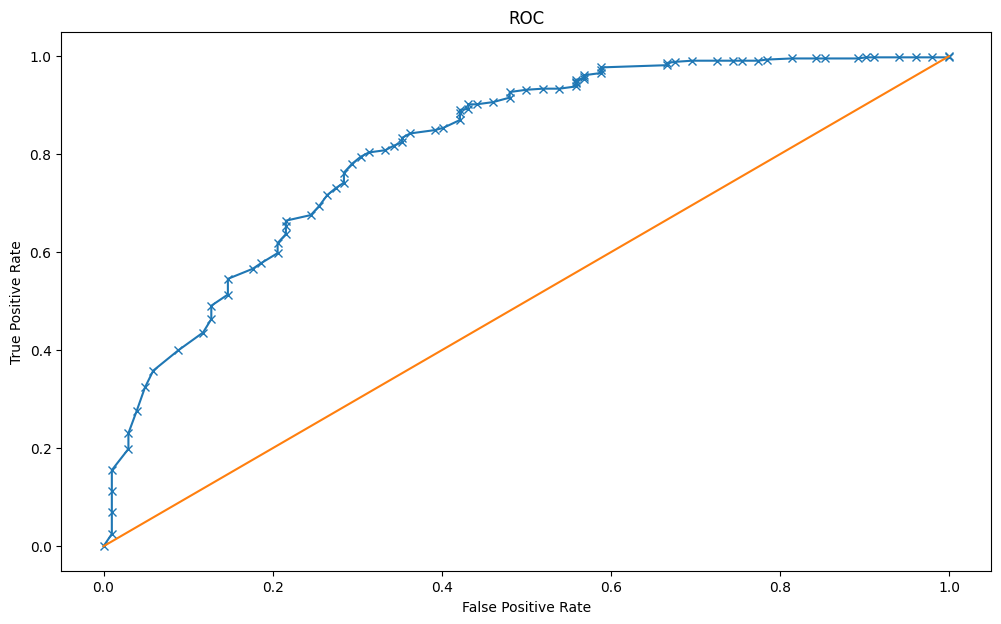

Area under Curve is 0.8134680812964455


In [ ]:
rf_fpr, rf_tpr,_=roc_curve(y_test,rfcl_smote.predict_proba(X_test)[:,1])
plt.figure(figsize=(12,7))
plt.plot(rf_fpr,rf_tpr, marker='x', label='Random Forest')
plt.plot(np.arange(0,1.1,0.1),np.arange(0,1.1,0.1))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC')
plt.show()
print('Area under Curve is', roc_auc_score(y_test,rfcl_smote.predict_proba(X_test)[:,1]))

In [ ]:
param_grid = {
    'max_depth': [5,7,10],
    'max_features': [6,7,8],
    'min_samples_leaf': [30,60,90],
    'min_samples_split': [90,180,270],
    'n_estimators': [100,200,300]
}

rfcl = RandomForestClassifier(random_state=0)

grid_search = GridSearchCV(estimator = rfcl, param_grid = param_grid, cv = 10)

In [ ]:
grid_search.fit(X_train_res, y_train_res)

GridSearchCV(cv=10, estimator=RandomForestClassifier(random_state=0),
             param_grid={'max_depth': [5, 7, 10], 'max_features': [6, 7, 8],
                         'min_samples_leaf': [30, 60, 90],
                         'min_samples_split': [90, 180, 270],
                         'n_estimators': [100, 200, 300]})

In [ ]:
grid_search.best_params_

{'max_depth': 10,
 'max_features': 6,
 'min_samples_leaf': 30,
 'min_samples_split': 90,
 'n_estimators': 200}

In [ ]:
best_grid_ran_smote = grid_search.best_estimator_

In [ ]:
best_grid_ran_smote

RandomForestClassifier(max_depth=10, max_features=6, min_samples_leaf=30,
                       min_samples_split=90, n_estimators=200, random_state=0)

In [ ]:
ytrain_predict = best_grid_ran_smote.predict(X_train_res)
ytest_predict = best_grid_ran_smote.predict(X_test)

In [ ]:
print(classification_report(y_train_res,ytrain_predict))

              precision    recall  f1-score   support

           0       0.83      0.84      0.83      1070
           1       0.83      0.82      0.83      1070

    accuracy                           0.83      2140
   macro avg       0.83      0.83      0.83      2140
weighted avg       0.83      0.83      0.83      2140



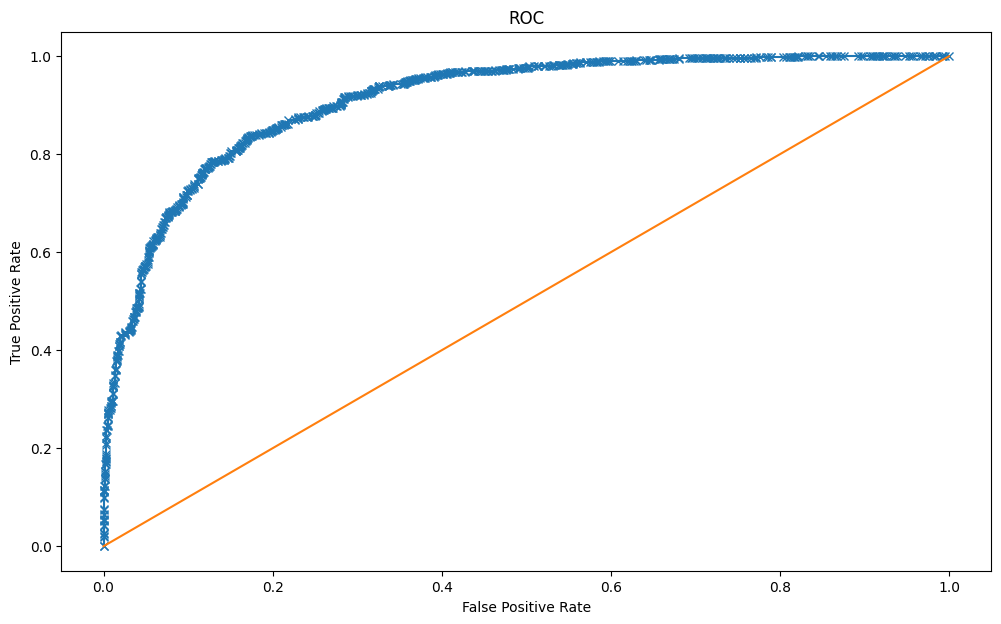

Area under Curve is 0.9106629399947593


In [ ]:
rf_fpr, rf_tpr,_=roc_curve(y_train_res,best_grid_ran_smote.predict_proba(X_train_res)[:,1])
plt.figure(figsize=(12,7))
plt.plot(rf_fpr,rf_tpr, marker='x', label='Random Forest')
plt.plot(np.arange(0,1.1,0.1),np.arange(0,1.1,0.1))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC')
plt.show()
print('Area under Curve is', roc_auc_score(y_train_res,best_grid_ran_smote.predict_proba(X_train_res)[:,1]))

In [ ]:
print(classification_report(y_test,ytest_predict))

              precision    recall  f1-score   support

           0       0.35      0.44      0.39       102
           1       0.86      0.81      0.84       438

    accuracy                           0.74       540
   macro avg       0.61      0.63      0.61       540
weighted avg       0.77      0.74      0.75       540



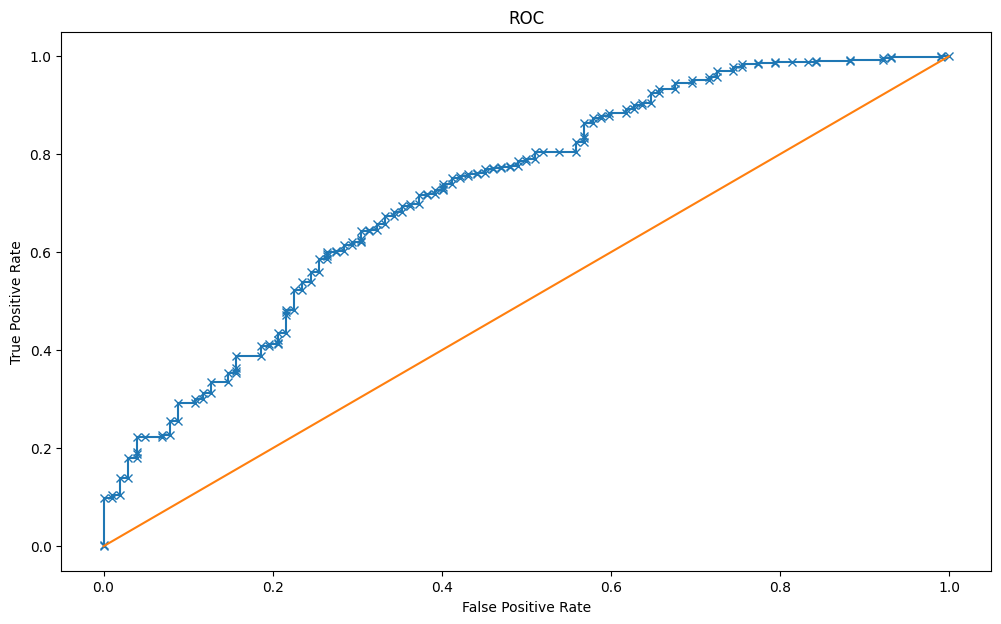

Area under Curve is 0.7247963112185514


In [ ]:
rf_fpr, rf_tpr,_=roc_curve(y_test,best_grid_ran_smote.predict_proba(X_test)[:,1])
plt.figure(figsize=(12,7))
plt.plot(rf_fpr,rf_tpr, marker='x', label='Random Forest')
plt.plot(np.arange(0,1.1,0.1),np.arange(0,1.1,0.1))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC')
plt.show()
print('Area under Curve is', roc_auc_score(y_test,best_grid_ran_smote.predict_proba(X_test)[:,1]))

## Adaboost after SMOTE

In [ ]:
ADB_model_smote = AdaBoostClassifier(n_estimators=100,random_state=1)
ADB_model_smote.fit(X_train_res, y_train_res)

AdaBoostClassifier(n_estimators=100, random_state=1)

In [ ]:
## Performance Matrix on train data set
y_train_predict = ADB_model_smote.predict(X_train_res)
model_score = ADB_model_smote.score(X_train_res, y_train_res)
print(model_score)
print(metrics.confusion_matrix(y_train_res, y_train_predict))
print(metrics.classification_report(y_train_res, y_train_predict))

0.8602803738317757
[[919 151]
 [148 922]]
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1070
           1       0.86      0.86      0.86      1070

    accuracy                           0.86      2140
   macro avg       0.86      0.86      0.86      2140
weighted avg       0.86      0.86      0.86      2140



AUC: 0.943


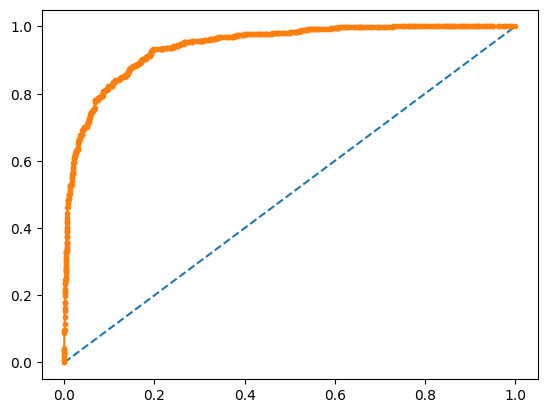

In [ ]:
# predict probabilities
probs = ADB_model_smote.predict_proba(X_train_res)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
auc = roc_auc_score(y_train_res, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
fpr, tpr, thresholds = roc_curve(y_train_res, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
# show the plot
plt.show()

In [ ]:
## Performance Matrix on test data set
y_test_predict = ADB_model_smote.predict(X_test)
model_score = ADB_model_smote.score(X_test, y_test)
print(model_score)
print(metrics.confusion_matrix(y_test, y_test_predict))
print(metrics.classification_report(y_test, y_test_predict))

0.7611111111111111
[[ 50  52]
 [ 77 361]]
              precision    recall  f1-score   support

           0       0.39      0.49      0.44       102
           1       0.87      0.82      0.85       438

    accuracy                           0.76       540
   macro avg       0.63      0.66      0.64       540
weighted avg       0.78      0.76      0.77       540



AUC: 0.740


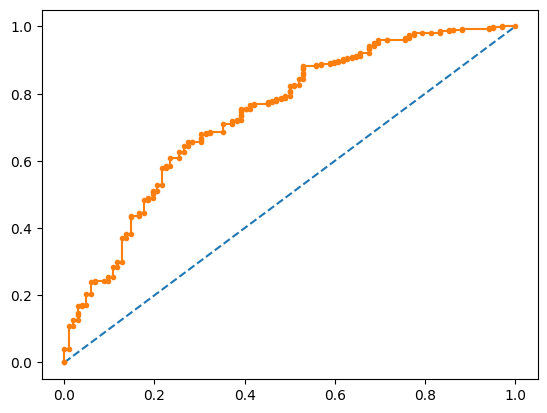

In [ ]:
# predict probabilities
probs = ADB_model_smote.predict_proba(X_test)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
auc = roc_auc_score(y_test, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
fpr, tpr, thresholds = roc_curve(y_test, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
# show the plot
plt.show()

## KNN Model after SMOTE

In [ ]:
KNN_model_smote=KNeighborsClassifier()
KNN_model_smote.fit(X_train_res, y_train_res)

KNeighborsClassifier()

In [ ]:
## Performance Matrix on train data set
y_train_predict = KNN_model_smote.predict(X_train_res)
model_score = KNN_model_smote.score(X_train_res, y_train_res)
print(model_score)
print(metrics.confusion_matrix(y_train_res, y_train_predict))
print(metrics.classification_report(y_train_res, y_train_predict))

0.9009345794392524
[[1063    7]
 [ 205  865]]
              precision    recall  f1-score   support

           0       0.84      0.99      0.91      1070
           1       0.99      0.81      0.89      1070

    accuracy                           0.90      2140
   macro avg       0.92      0.90      0.90      2140
weighted avg       0.92      0.90      0.90      2140



AUC: 0.991


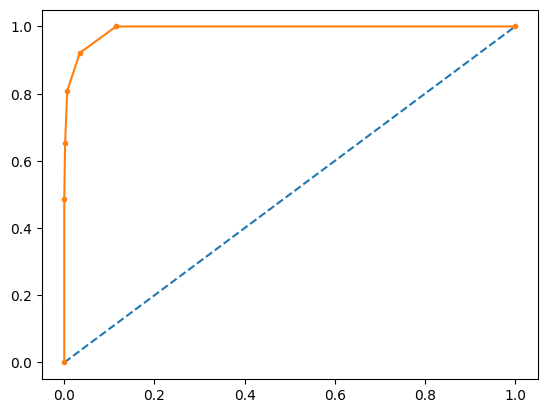

In [ ]:
# predict probabilities
probs = KNN_model_smote.predict_proba(X_train_res)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
auc = roc_auc_score(y_train_res, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
fpr, tpr, thresholds = roc_curve(y_train_res, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
# show the plot
plt.show()

In [ ]:
## Performance Matrix on test data set
y_test_predict = KNN_model_smote.predict(X_test)
model_score = KNN_model_smote.score(X_test, y_test)
print(model_score)
print(metrics.confusion_matrix(y_test, y_test_predict))
print(metrics.classification_report(y_test, y_test_predict))

0.6777777777777778
[[ 56  46]
 [128 310]]
              precision    recall  f1-score   support

           0       0.30      0.55      0.39       102
           1       0.87      0.71      0.78       438

    accuracy                           0.68       540
   macro avg       0.59      0.63      0.59       540
weighted avg       0.76      0.68      0.71       540



AUC: 0.678


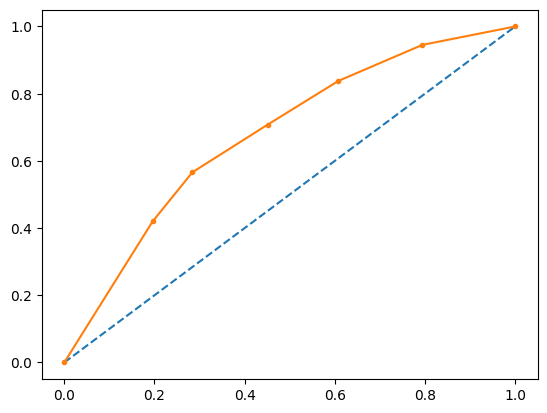

In [ ]:
# predict probabilities
probs = KNN_model_smote.predict_proba(X_test)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
auc = roc_auc_score(y_test, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
fpr, tpr, thresholds = roc_curve(y_test, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
# show the plot
plt.show()

## Naive Bayes Model after Smote

In [ ]:
NB_model_smote = GaussianNB()
NB_model_smote.fit(X_train_res, y_train_res)

GaussianNB()

In [ ]:
## Performance Matrix on train data set
y_train_predict = NB_model_smote.predict(X_train_res)
model_score = NB_model_smote.score(X_train_res, y_train_res)
print(model_score)
print(metrics.confusion_matrix(y_train_res, y_train_predict))
print(metrics.classification_report(y_train_res, y_train_predict))

0.7285046728971962
[[849 221]
 [360 710]]
              precision    recall  f1-score   support

           0       0.70      0.79      0.75      1070
           1       0.76      0.66      0.71      1070

    accuracy                           0.73      2140
   macro avg       0.73      0.73      0.73      2140
weighted avg       0.73      0.73      0.73      2140



AUC: 0.818


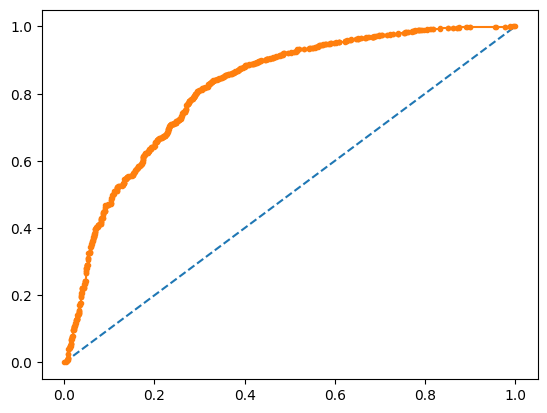

In [ ]:
# predict probabilities
probs = NB_model_smote.predict_proba(X_train_res)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
auc = roc_auc_score(y_train_res, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
fpr, tpr, thresholds = roc_curve(y_train_res, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
# show the plot
plt.show()

In [ ]:
## Performance Matrix on test data set
y_test_predict = NB_model_smote.predict(X_test)
model_score = NB_model_smote.score(X_test, y_test)
print(model_score)
print(metrics.confusion_matrix(y_test, y_test_predict))
print(metrics.classification_report(y_test, y_test_predict))

0.6611111111111111
[[ 57  45]
 [138 300]]
              precision    recall  f1-score   support

           0       0.29      0.56      0.38       102
           1       0.87      0.68      0.77       438

    accuracy                           0.66       540
   macro avg       0.58      0.62      0.58       540
weighted avg       0.76      0.66      0.69       540



AUC: 0.694


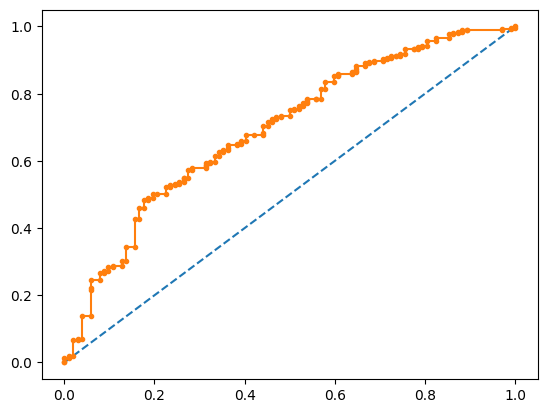

In [ ]:
# predict probabilities
probs = NB_model_smote.predict_proba(X_test)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
auc = roc_auc_score(y_test, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
fpr, tpr, thresholds = roc_curve(y_test, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
# show the plot
plt.show()

## XGBoost after SMOTE

In [ ]:
xgb_smote = XGBClassifier(random_state=1,enable_categorical=True)
xgb_smote.fit(X_train_res, y_train_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=1, ...)

In [ ]:
## Performance Matrix on train data set
y_train_predict = xgb_smote.predict(X_train_res)
model_score = xgb_smote.score(X_train_res, y_train_res)
print(model_score)
print(metrics.confusion_matrix(y_train_res, y_train_predict))
print(metrics.classification_report(y_train_res, y_train_predict))

1.0
[[1070    0]
 [   0 1070]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1070
           1       1.00      1.00      1.00      1070

    accuracy                           1.00      2140
   macro avg       1.00      1.00      1.00      2140
weighted avg       1.00      1.00      1.00      2140



AUC: 1.000


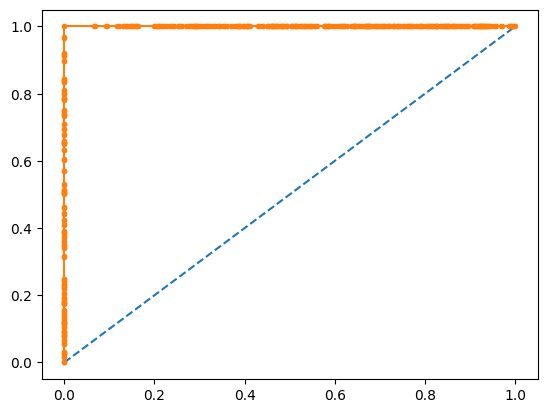

In [ ]:
# predict probabilities
probs = xgb_smote.predict_proba(X_train_res)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
auc = roc_auc_score(y_train_res, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
fpr, tpr, thresholds = roc_curve(y_train_res, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
# show the plot
plt.show()

In [ ]:
## Performance Matrix on test data set
y_test_predict = xgb_smote.predict(X_test)
model_score = xgb_smote.score(X_test, y_test)
print(model_score)
print(metrics.confusion_matrix(y_test, y_test_predict))
print(metrics.classification_report(y_test, y_test_predict))

0.8629629629629629
[[ 51  51]
 [ 23 415]]
              precision    recall  f1-score   support

           0       0.69      0.50      0.58       102
           1       0.89      0.95      0.92       438

    accuracy                           0.86       540
   macro avg       0.79      0.72      0.75       540
weighted avg       0.85      0.86      0.85       540



AUC: 0.787


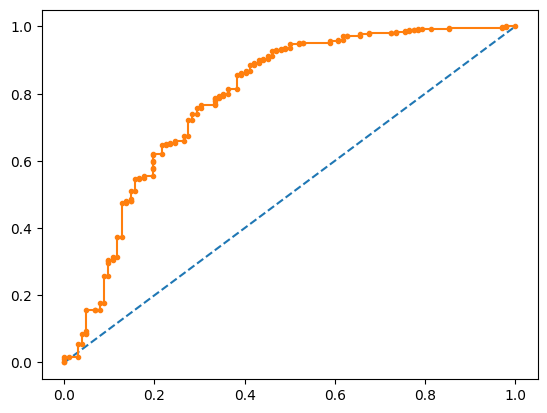

In [ ]:
# predict probabilities
probs = xgb_smote.predict_proba(X_test)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
auc = roc_auc_score(y_test, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
fpr, tpr, thresholds = roc_curve(y_test, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
# show the plot
plt.show()

## Comparing models after performing SMOTE

In [ ]:
# defining list of models
models = [dTree_smote, best_grid_ran_smote, ADB_model_smote, KNN_model_smote, NB_model_smote, xgb_smote]

# defining empty lists to add train and test results
acc_train = []
acc_test = []
recall_train = []
recall_test = []
precision_train = []
precision_test = []
f1_train = []
f1_test = []

# looping through all the models to get the accuracy, precall and precision scores
for model in models:
    j = get_metrics_score(model,False)
    acc_train.append(np.round(j[0],2))
    acc_test.append(np.round(j[1],2))
    recall_train.append(np.round(j[2],2))
    recall_test.append(np.round(j[3],2))
    precision_train.append(np.round(j[4],2))
    precision_test.append(np.round(j[5],2))
    f1_train.append(np.round(j[6],2))
    f1_test.append(np.round(j[7],2))

In [ ]:
comparison_frame = pd.DataFrame({'Model':['Decision Tree after SMOTE','Random forest with grid search CV after SMOTE',
                                          'Adaboost after SMOTE','KNN model after SMOTE',
                                          'Naive Bayes model after SMOTE','XGBoost with default parameters after SMOTE'],
                                          'Train_Accuracy': acc_train,'Test_Accuracy': acc_test,
                                          'Train_Recall':recall_train,'Test_Recall':recall_test,
                                          'Train_Precision':precision_train,'Test_Precision':precision_test,
                                          'Train_f1score':f1_train,'Test_f1score':f1_test})
comparison_frame

,Model,Train_Accuracy,Test_Accuracy,Train_Recall,Test_Recall,Train_Precision,Test_Precision,Train_f1score,Test_f1score
0,Decision Tree after SMOTE,1.00,0.79,1.00,0.87,1.00,0.88,1.00,0.87
1,Random forest with grid search CV after SMOTE,0.80,0.74,0.82,0.81,0.93,0.86,0.87,0.84
2,Adaboost after SMOTE,0.83,0.76,0.86,0.82,0.93,0.87,0.90,0.85
3,KNN model after SMOTE,0.83,0.68,0.81,0.71,1.00,0.87,0.89,0.78
4,Naive Bayes model after SMOTE,0.66,0.66,0.66,0.68,0.91,0.87,0.77,0.77
5,XGBoost with default parameters after SMOTE,1.00,0.86,1.00,0.95,1.00,0.89,1.00,0.92


As seen above we can say that Random forest with grid search CV,Adaboost, KNN model and Naive Bayes have the f1score less than 1 which indicates that these models are not over fit.

Decision Tree and XG boost on the other hand have an f1 score of 1 for the train data indicating that the model could be overfit.

We can say that Random forest with grid search CV after SMOTE can be considered as the best performing model as it shows a good balance between training and testing performance (test accuracy: 0.82, test F1 score: 0.87).

## Test on the Given Series Condition:

Before we proceed we will first identify the important features of the model selected.

In [ ]:
print(pd.DataFrame(best_grid_ran.feature_importances_,index= X_train.columns,columns=['imp']).sort_values(by = 'imp',ascending=False))

                             imp
Offshore                0.341314
Extra_bowls_bowled      0.179953
player_highest_wicket   0.159050
Opponent                0.065778
All_rounder_in_team     0.059295
Min_run_given_1over     0.042975
extra_bowls_opponent    0.036524
Min_run_scored_1over    0.026500
Match_format            0.025000
Max_wicket_taken_1over  0.014555
Players_scored_zero     0.013630
Max_run_scored_1over    0.013308
Max_run_given_1over     0.009124
Match_light_type        0.008523
First_selection         0.004470


### 1 Test match with England in England. All the match are day matches. In England, it will be rainy season at the time to match

In [ ]:
# As per encoding the value of England  is 2 so we will be mentioning 2 in the opponent column

df_query = cric_model.head(1)
df_query['Opponent'] = 2
df_query['Match_light_type'] = 0
df_query['Match_format'] = 2
df_query['Offshore'] = 1

<ipython-input-244-720b8a877d80>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_query['Opponent'] = 2
<ipython-input-244-720b8a877d80>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_query['Match_light_type'] = 0
<ipython-input-244-720b8a877d80>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.ht

In [ ]:
df_query.drop(columns = ['Result'],axis = 0, inplace = True)

<ipython-input-245-1d04dd22e612>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_query.drop(columns = ['Result'],axis = 0, inplace = True)


In [ ]:
best_grid_ran.predict(df_query)

array([1])

### 2 T20 match with Australia in India. All the match are Day and Night matches. In India, it will be winter season at the time to match.

In [ ]:
# As per encoding the value of Australia is 0 so we will be mentioning 0 in the opponent column

df_query = cric_model.head(1)
df_query['Opponent'] = 0
df_query['Match_light_type'] = 1
df_query['Match_format'] = 1
df_query['Offshore'] = 0

<ipython-input-247-1a5372686fa4>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_query['Opponent'] = 0
<ipython-input-247-1a5372686fa4>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_query['Match_light_type'] = 1
<ipython-input-247-1a5372686fa4>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.ht

In [ ]:
df_query.drop(columns = ['Result'],axis = 0, inplace = True)

<ipython-input-248-1d04dd22e612>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_query.drop(columns = ['Result'],axis = 0, inplace = True)


In [ ]:
best_grid_ran.predict(df_query)

array([1])

### 2 ODI match with Sri Lanka in India. All the match are Day and Night matches. In India, it will be winter season at the time to match.

In [ ]:
# As per encoding the value of Srilanka is 6 so we will be mentioning 6 in the opponent column

df_query = cric_model.head(1)
df_query['Opponent'] = 6
df_query['Match_light_type'] = 1
df_query['Match_format'] = 0
df_query['Offshore'] = 0

<ipython-input-250-e22160742b70>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_query['Opponent'] = 6
<ipython-input-250-e22160742b70>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_query['Match_light_type'] = 1
<ipython-input-250-e22160742b70>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.ht

In [ ]:
df_query.drop(columns = ['Result'],axis = 0, inplace = True)

<ipython-input-251-1d04dd22e612>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_query.drop(columns = ['Result'],axis = 0, inplace = True)


In [ ]:
best_grid_ran.predict(df_query)

array([1])